# ADMF Projeto

In [1280]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.seasonal import STL
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from curl_cffi import requests

In [1281]:
# from alpha_vantage.timeseries import TimeSeries
# APIKEY="MVGIQOUW3UJGQ1IT"
# ts = TimeSeries(key= APIKEY, output_format= 'pandas')
# data_df_etf, meta_data_etf = ts.get_daily(symbol='IQQH.DE')
# data_df_stock, meta_data_stock = ts.get_daily(symbol='ENPH')
# print(data_df_etf)
# print(meta_data_etf)
# print(data_df_stock)
# print(meta_data_stock)
# close_prices_etf = data_df_etf['4. close']
# close_prices_stock = data_df_stock['4. close']
# print(close_prices_etf)
# print(close_prices_stock)

In [1282]:
# combined_df = pd.concat([close_prices_etf, close_prices_stock], axis=1)
# combined_df.columns = ['IQQH.DE Close', 'ENPH Close']
# combined_df = combined_df.fillna(combined_df.mean())
# combined_df = combined_df.reset_index().rename(columns={'index': 'Date'})
# combined_df.to_excel('close_prices.xlsx', index=False)

In [1283]:
# etf = "IQQH.DE"
# top_30_clean_energy_holdings = [
#     "IQQH.DE",
#     "IBE.MC",      # Iberdrola SA (Madrid)
#     "SSE.L",       # SSE PLC (London)
#     "VWS.CO",      # Vestas Wind Systems (Copenhagen)
#     "FSLR",        # First Solar Inc (NASDAQ)
#     "600900.SS",   # China Yangtze Power A (Shanghai)
#     "ENPH",        # Enphase Energy Inc (NASDAQ)
#     "EDP.LS",      # EDP Energias de Portugal (Lisbon)
#     "NXT",         # Nextracker Inc (NASDAQ)
#     "EQTL3.SA",    # Equatorial SA (São Paulo)
#     "9502.T",      # Chubu Electric Power (Tokyo)
#     "ORSTED.CO",   # Ørsted (Copenhagen)
#     "SUZLON.NS",   # Suzlon Energy Ltd (NSE India)
#     "ELET3.SA",    # Eletrobras (São Paulo)
#     "ORA",         # Ormat Technologies (NYSE)
#     "NHPC.NS",     # NHPC Ltd (NSE India)
#     "NPI.TO",      # Northland Power Inc (Toronto)
#     "CMIG4.SA",    # CEMIG (São Paulo)
#     "CWEN",        # Clearway Energy (NYSE)
#     "NDX1.DE",     # Nordex SE (Xetra)
#     "ENGI11.SA",   # Energisa Units (São Paulo)
#     "EDPR.LS",     # EDP Renováveis (Lisbon)
#     "EGIE3.SA",    # Engie Brasil Energia (São Paulo)
#     "VER.VI",      # Verbund AG (Vienna)
#     "BKW.SW",      # BKW AG (Swiss)
#     "BEPC",        # Brookfield Renewable (NYSE)
#     "CPLE6.SA",    # COPEL (São Paulo)
#     "BLX.TO",      # Boralex Inc (Toronto)
#     "600905.SS",   # China Three Gorges Renewables (Shanghai)
#     "300274.SZ",    # Sungrow Power Supply (Shenzhen)
#     "601012.SS"
# ]
# # news = yf.Search("Google", news_count=10).news
# start_date = "2023-01-01"
# end_date = "2025-01-01"
# def get_stock_data(tickers):
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         session = requests.Session(impersonate=tickers)
#         data = yf.download(tickers, start="2023-01-01", end="2025-01-01",session=session)['Close']
#     return data.dropna()


# prices_1 = get_stock_data(etf)
# prices_2 = get_stock_data(top_30_clean_energy_holdings)

# prices = "" # prices_1 + prices_2
# # Daily returns -- This can also be calculated with normal prices, but lets try with daily returns 
# returns = prices_2.pct_change().dropna()

In [1284]:
caminho_excel = r'ADMF_Projeto\Stocks_David_Afonso.xlsx'
data = pd.read_excel(caminho_excel, index_col='Date', parse_dates=True)
def custom_fill(series):
    filled_series = series.copy()
    nan_positions = filled_series[filled_series.isna()].index
    
    for idx, pos in enumerate(nan_positions):
        # Converter posição timestamp para índice numérico
        numeric_idx = filled_series.index.get_loc(pos)
        window = []
        
        # Tentar 2 anteriores e 2 posteriores
        if numeric_idx >= 2 and numeric_idx <= len(filled_series) - 3:
            window = filled_series.iloc[numeric_idx-2:numeric_idx].tolist() + \
                     filled_series.iloc[numeric_idx+1:numeric_idx+3].tolist()
        elif numeric_idx >= 2:  # Tentar apenas anteriores
            window = filled_series.iloc[numeric_idx-2:numeric_idx].tolist()
        elif numeric_idx <= len(filled_series) - 3:  # Tentar apenas posteriores
            window = filled_series.iloc[numeric_idx+1:numeric_idx+3].tolist()
        
        # Filtrar valores válidos e calcular média
        valid_values = [x for x in window if pd.notnull(x)]
        if len(valid_values) >= 1:
            filled_series.iloc[numeric_idx] = sum(valid_values)/len(valid_values)
            continue
            
        # Fallback 1: média rolling
        filled_series = filled_series.fillna(
            filled_series.rolling(10, min_periods=1).mean().shift()
        )
        
        # Fallback final: média global
        if pd.isnull(filled_series.iloc[numeric_idx]):
            filled_series.iloc[numeric_idx] = filled_series.mean()
    
    return filled_series

data = data.apply(custom_fill)
returns = data
returns

,300274.SZ,600900.SS,600905.SS,601012.SS,9502.T,BEPC,BKW.SW,BLX.TO,CMIG4.SA,CPLE6.SA,...,NDX1.DE,NHPC.NS,NPI.TO,NXT,ORA,ORSTED.CO,SSE.L,SUZLON.NS,VER.VI,VWS.CO
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,80.074825,19.406011,5.652054,40.292995,1217.215454,25.595903,123.577484,38.977028,6.257369,7.160942,...,12.8650,36.759354,33.333078,41.701777,83.751854,634.930725,1647.848083,10.700000,72.783661,200.449890
2023-01-03,81.255592,19.443205,5.661749,40.965519,1217.215454,25.336000,121.258339,39.034317,6.108248,7.029720,...,12.8550,36.621334,33.328651,41.701777,83.815918,640.994446,1661.834106,10.750000,72.323586,199.505783
2023-01-04,78.894058,19.368816,5.642359,39.620472,1217.215454,25.855806,125.896629,38.919739,6.182808,7.226553,...,12.7650,36.575325,33.337505,41.701777,83.687790,649.405396,1633.862061,10.400000,68.689003,190.372726
2023-01-05,80.060768,19.313026,5.652054,40.029835,1217.215454,24.878931,120.974358,38.852898,6.240163,7.170315,...,12.8900,36.069256,32.584671,41.701777,82.574051,618.695557,1648.347290,10.250000,69.287109,193.393906
2023-01-06,84.411369,19.424606,5.787780,41.589306,1197.836060,25.264303,126.085945,39.530842,6.240163,7.067212,...,13.4700,36.391300,33.372925,41.701777,83.796196,623.976868,1673.322266,10.200000,69.057068,198.810120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,77.900002,29.570496,4.510000,16.360001,1597.381592,28.048273,146.972404,28.892414,10.175617,9.120000,...,11.5350,80.070568,17.644776,36.835001,68.923477,332.883336,1605.454468,64.080000,67.290972,97.399236
2024-12-26,78.000000,29.103956,4.450000,16.190001,1601.802368,28.008810,146.923523,28.787995,10.200757,9.090000,...,11.4275,80.489990,17.610719,36.970001,69.133125,330.258336,1607.204254,64.339996,67.255034,97.255134
2024-12-27,75.680000,29.391821,4.450000,16.150000,1623.906372,27.811497,148.308517,28.759819,10.191525,9.170000,...,11.3100,78.812302,17.631804,37.230000,67.795387,330.299988,1606.787598,63.250000,67.706253,98.227402


In [1285]:
def rsi(series, period=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

Principal components: 2


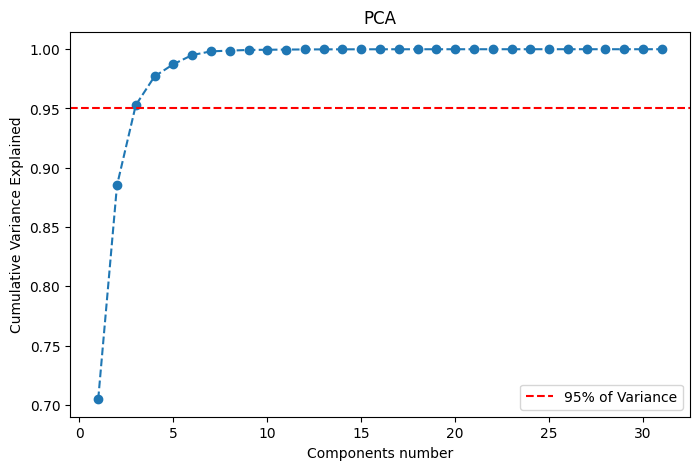

In [1286]:
corr_matrix = returns.corr()
corr_with_iqqh = corr_matrix["IQQH.DE"].drop("IQQH.DE")
X = corr_matrix.values
X_scaled = StandardScaler().fit_transform(X)  # Transpose --> this will put the prices on the top of columns,
                                                    #to identify components 

# PCA
pca = PCA()
pca.fit(X_scaled)

# Cumulative Variance Explained
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Determine the number of components for 95% of the variance explained
n_components = np.argmax(explained_variance >= 0.8) + 1
print(f"Principal components: {n_components}")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% of Variance')
plt.xlabel('Components number')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA')
plt.legend()
plt.show()

In [1287]:
for n in [2, 3, 4, 5, 6]:  # Test different number of components
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)
    
    dbscan = DBSCAN(eps=4, min_samples=2) #select the best EPS paramter --> bigger EPS, bigger clusters
    labels = dbscan.fit_predict(X_pca)
    
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"For {n} components, DBSCAN found {num_clusters} clusters")

For 2 components, DBSCAN found 1 clusters
For 3 components, DBSCAN found 1 clusters
For 4 components, DBSCAN found 1 clusters
For 5 components, DBSCAN found 2 clusters
For 6 components, DBSCAN found 2 clusters


In [1288]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dbscan = DBSCAN(eps=5, min_samples=2)  # choose the best parameters --> bigger EPS, bigger clusters
labels = dbscan.fit_predict(X_pca)

corr_matrix['Cluster'] = labels

# Encontrar cluster do IQQH.DE
iqqh_cluster = corr_matrix.loc["IQQH.DE", "Cluster"]

# Filtrar ativos no mesmo cluster
pares_potenciais = corr_matrix[corr_matrix['Cluster'] == iqqh_cluster].index

# Remover o próprio IQQH.DE e o cluster
pares_potenciais = pares_potenciais.drop("IQQH.DE")

# Ordenar por correlação com IQQH.DE e pegar os top 10
top_10_pares = corr_with_iqqh.loc[pares_potenciais].sort_values(ascending=False).head(10)

# Ordenar por correlação com IQQH.DE
melhores_pares = corr_with_iqqh.loc[pares_potenciais].sort_values(ascending=False)

print("Melhores pares para IQQH.DE:")
print(melhores_pares.head(10))

pairs = [('IQQH.DE', ativo) for ativo in top_10_pares.index]
print(pairs)

clusters = {}
tickers = returns.columns

for ticker, cluster in zip(tickers, labels):
    if cluster == -1:  # -1 noise points 
        continue
    if cluster not in clusters:
        clusters[cluster] = []
    clusters[cluster].append(ticker)

print("\n")
print("Clusters:")
for i in clusters:
    print(clusters[i])

Melhores pares para IQQH.DE:
ENPH         0.965395
NPI.TO       0.923183
ORSTED.CO    0.913522
601012.SS    0.900438
EDPR.LS      0.899448
600905.SS    0.873190
EDP.LS       0.800727
ORA          0.778370
BLX.TO       0.743924
VWS.CO       0.632582
Name: IQQH.DE, dtype: float64
[('IQQH.DE', 'ENPH'), ('IQQH.DE', 'NPI.TO'), ('IQQH.DE', 'ORSTED.CO'), ('IQQH.DE', '601012.SS'), ('IQQH.DE', 'EDPR.LS'), ('IQQH.DE', '600905.SS'), ('IQQH.DE', 'EDP.LS'), ('IQQH.DE', 'ORA'), ('IQQH.DE', 'BLX.TO'), ('IQQH.DE', 'VWS.CO')]


Clusters:
['300274.SZ', '600900.SS', '600905.SS', '601012.SS', '9502.T', 'BEPC', 'BKW.SW', 'BLX.TO', 'CMIG4.SA', 'CPLE6.SA', 'CWEN', 'EDP.LS', 'EDPR.LS', 'EGIE3.SA', 'ELET3.SA', 'ENGI11.SA', 'ENPH', 'EQTL3.SA', 'FSLR', 'IBE.MC', 'IQQH.DE', 'NDX1.DE', 'NHPC.NS', 'NPI.TO', 'NXT', 'ORA', 'ORSTED.CO', 'SSE.L', 'SUZLON.NS', 'VER.VI', 'VWS.CO']


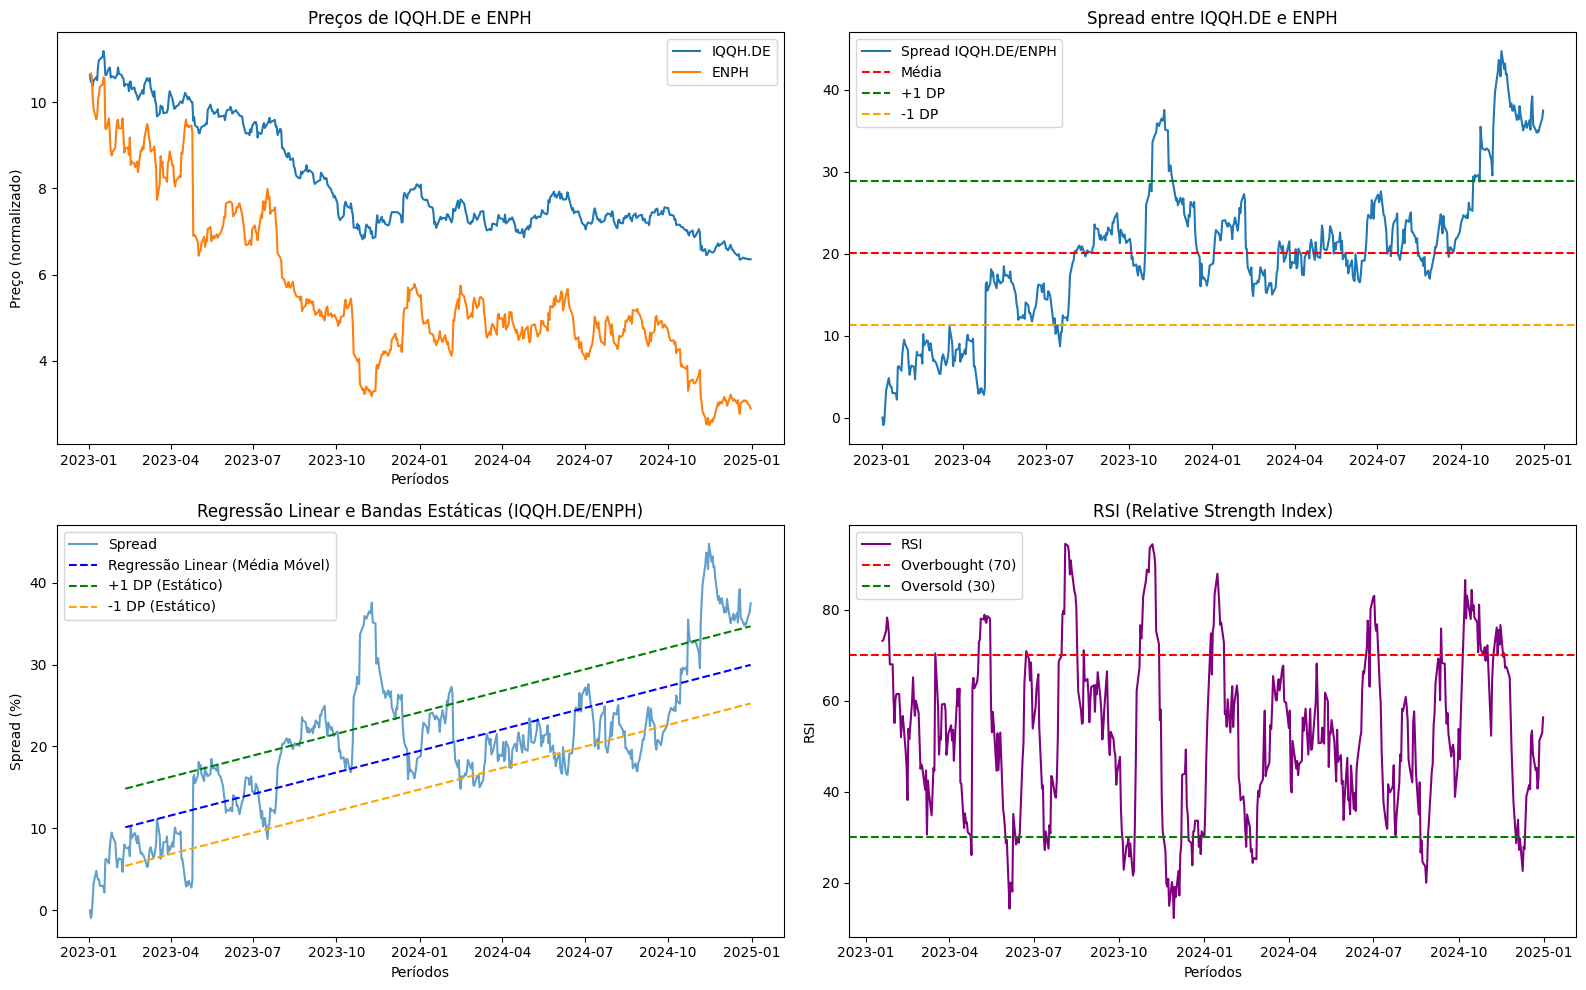

Par: IQQH.DE - ENPH | P-Valor ADF: 0.2371
NOT Stationary.

Correlation between IQQH.DE and ENPH: 0.97

Cointegration Test Statistic: -4.23
P-Value: 0.00332
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and ENPH is cointegrated (p-value < 0.05).


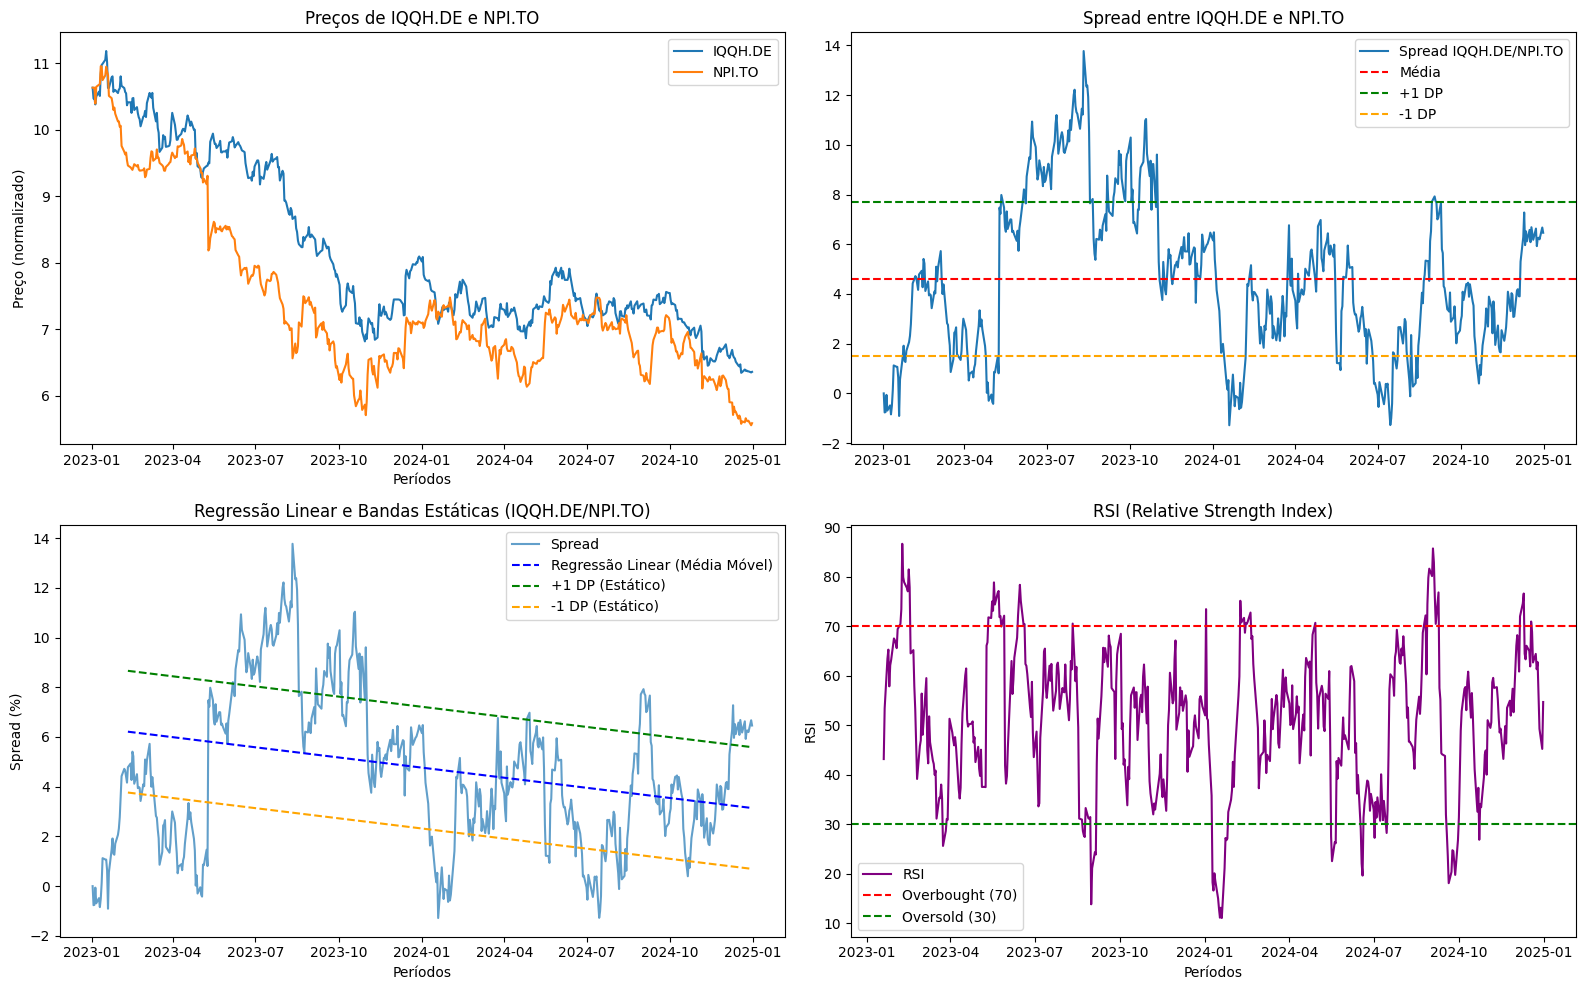

Par: IQQH.DE - NPI.TO | P-Valor ADF: 0.0158
Stationary.

Correlation between IQQH.DE and NPI.TO: 0.92

Cointegration Test Statistic: -3.04
P-Value: 0.10045
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and NPI.TO is NOT cointegrated (p-value >= 0.05).


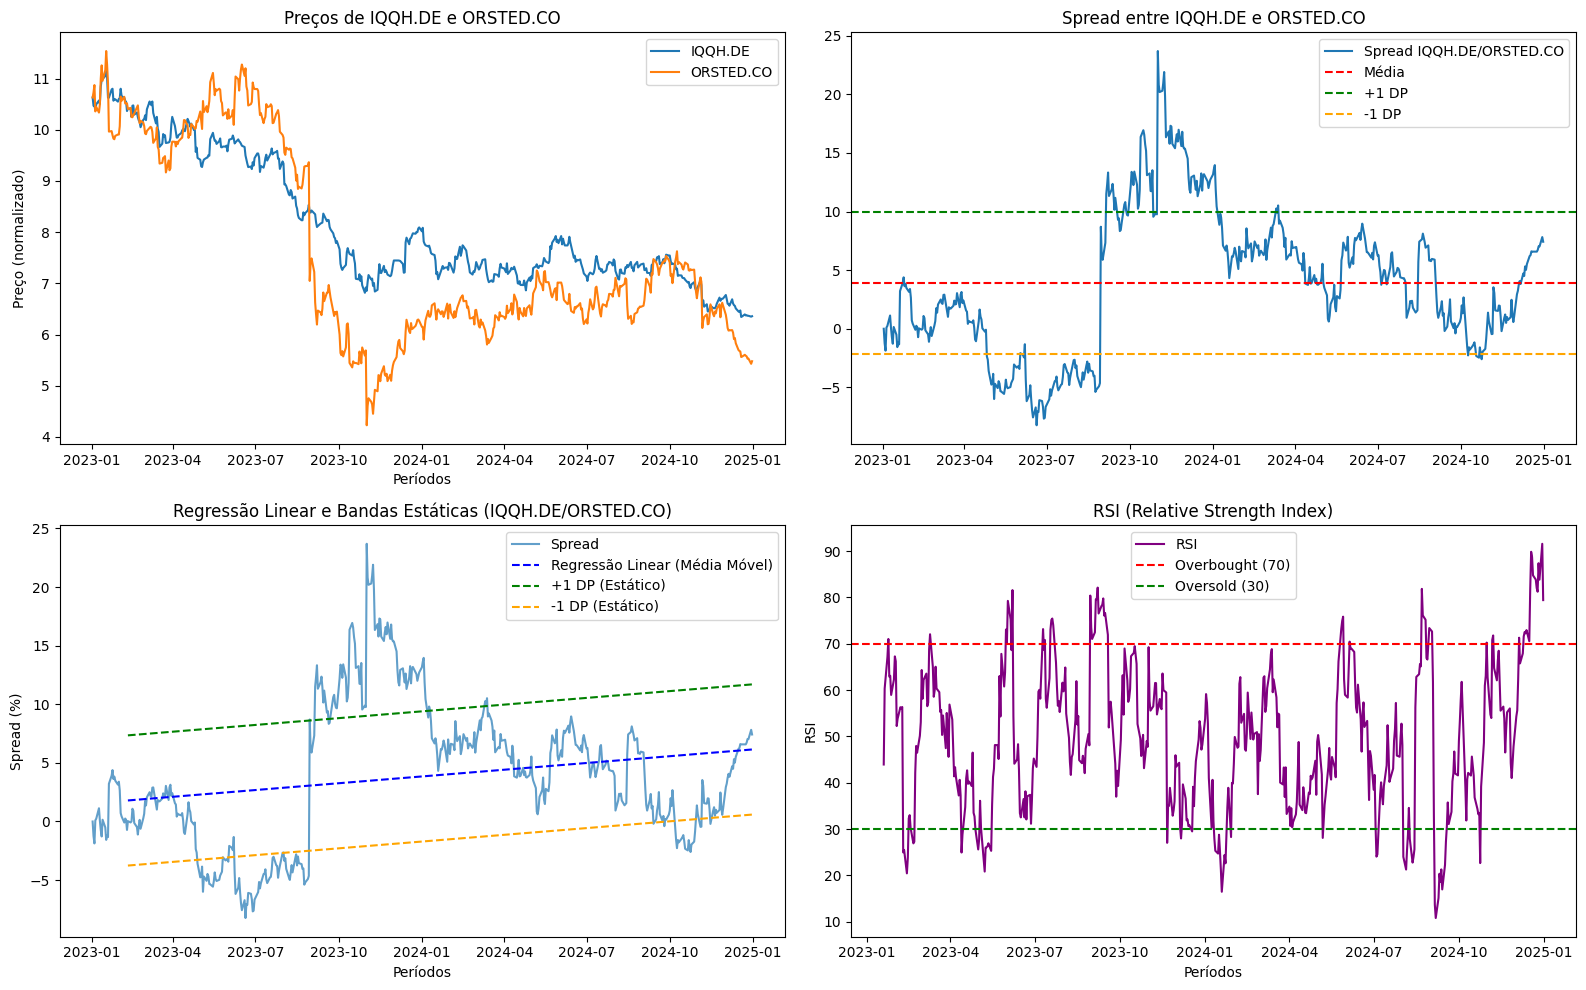

Par: IQQH.DE - ORSTED.CO | P-Valor ADF: 0.1590
NOT Stationary.

Correlation between IQQH.DE and ORSTED.CO: 0.91

Cointegration Test Statistic: -2.92
P-Value: 0.13115
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and ORSTED.CO is NOT cointegrated (p-value >= 0.05).


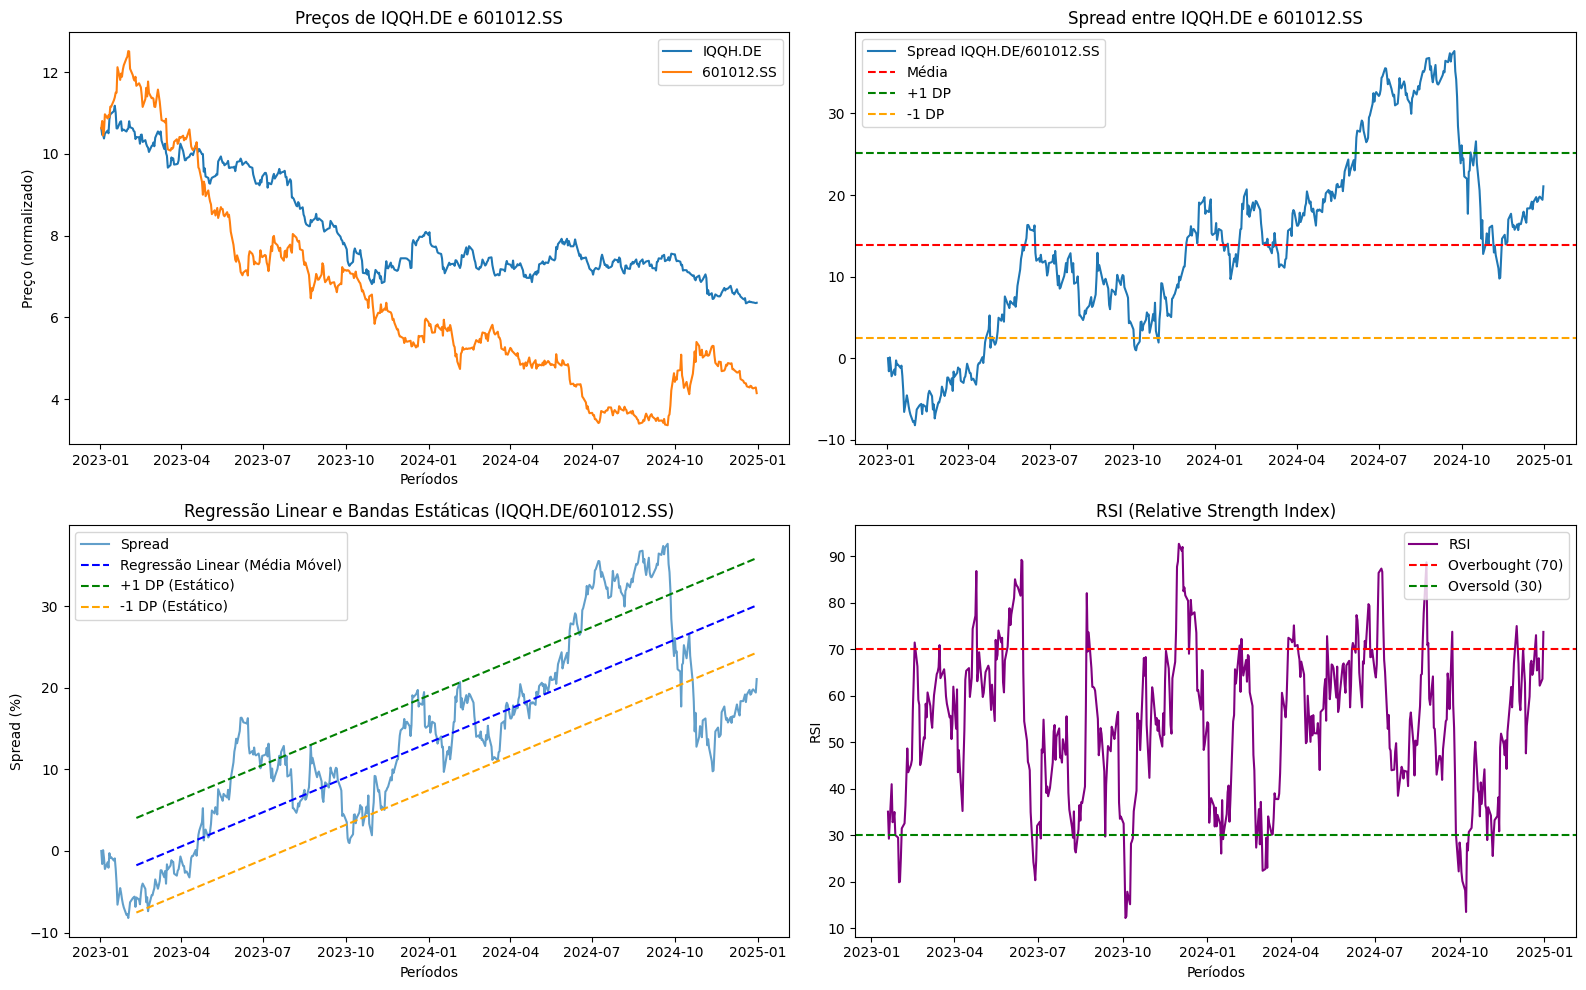

Par: IQQH.DE - 601012.SS | P-Valor ADF: 0.5225
NOT Stationary.

Correlation between IQQH.DE and 601012.SS: 0.90

Cointegration Test Statistic: -2.49
P-Value: 0.28164
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and 601012.SS is NOT cointegrated (p-value >= 0.05).


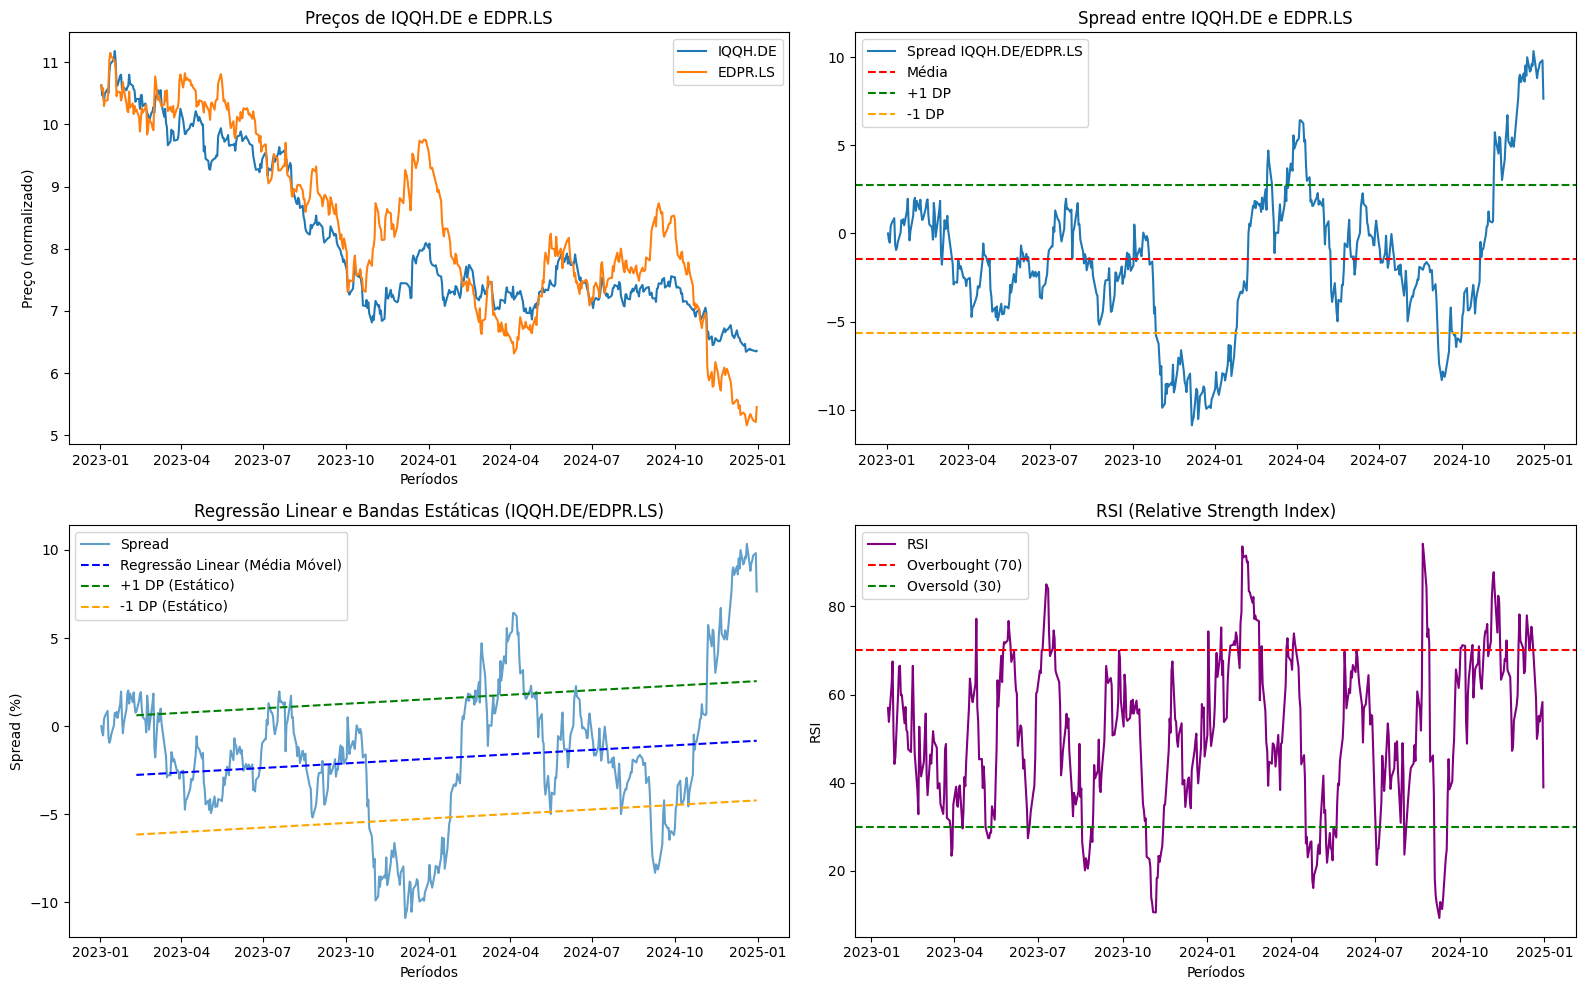

Par: IQQH.DE - EDPR.LS | P-Valor ADF: 0.4260
NOT Stationary.

Correlation between IQQH.DE and EDPR.LS: 0.90

Cointegration Test Statistic: -2.41
P-Value: 0.32086
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and EDPR.LS is NOT cointegrated (p-value >= 0.05).


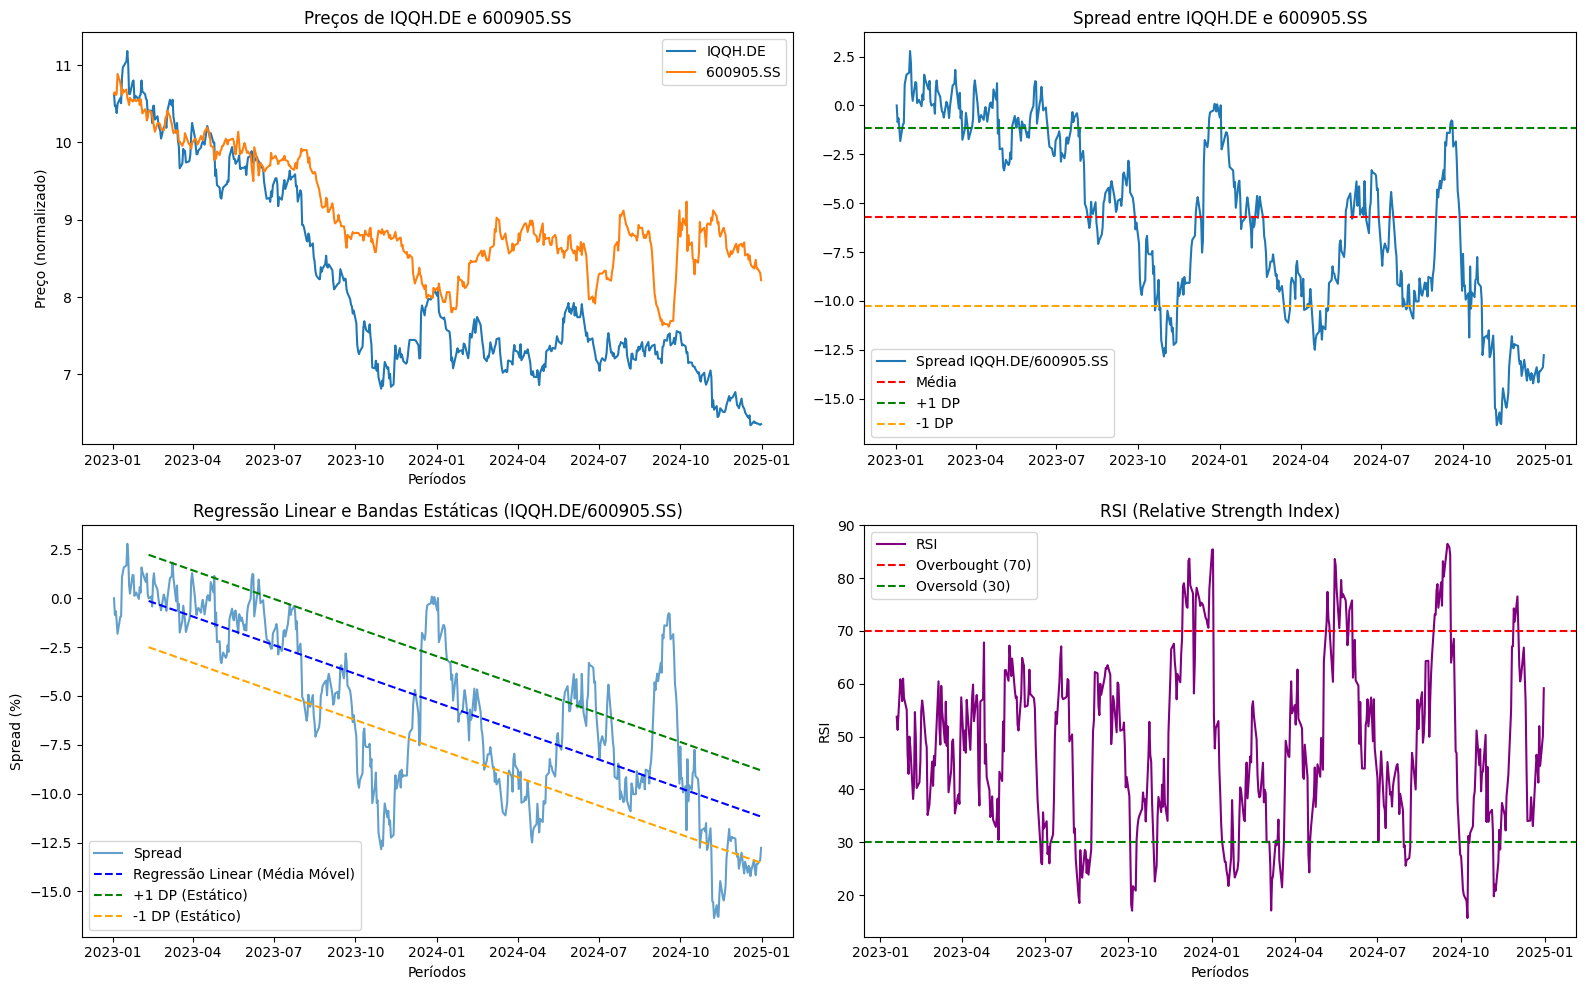

Par: IQQH.DE - 600905.SS | P-Valor ADF: 0.3710
NOT Stationary.

Correlation between IQQH.DE and 600905.SS: 0.87

Cointegration Test Statistic: -3.43
P-Value: 0.03950
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and 600905.SS is cointegrated (p-value < 0.05).


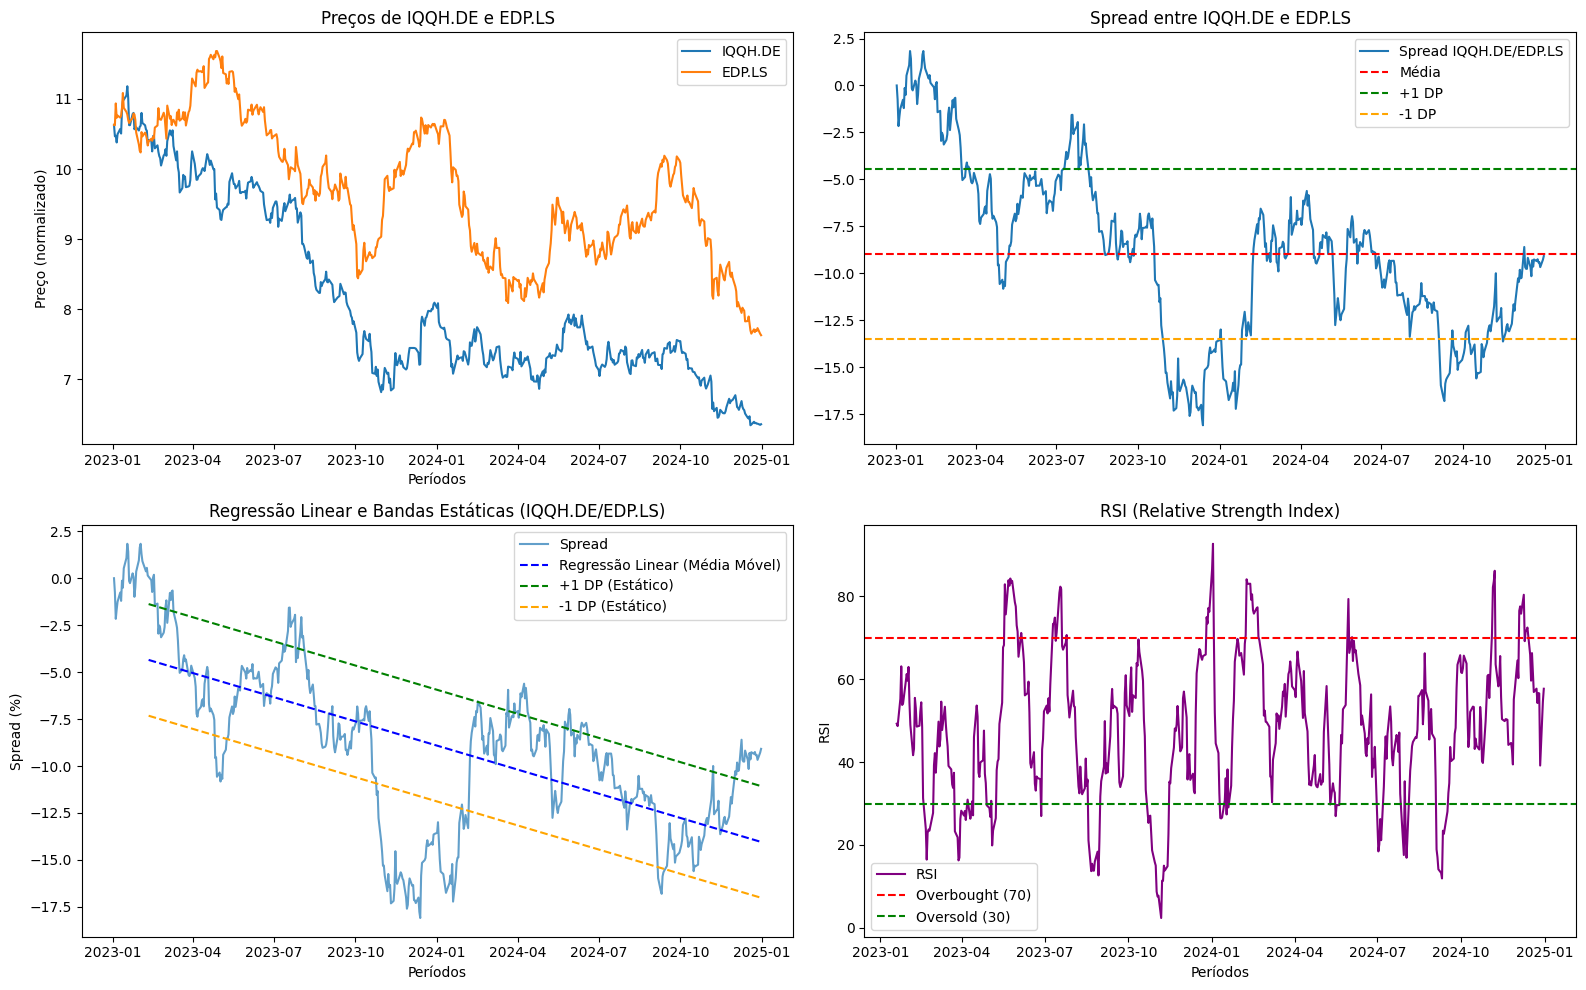

Par: IQQH.DE - EDP.LS | P-Valor ADF: 0.1687
NOT Stationary.

Correlation between IQQH.DE and EDP.LS: 0.80

Cointegration Test Statistic: -2.42
P-Value: 0.31402
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and EDP.LS is NOT cointegrated (p-value >= 0.05).


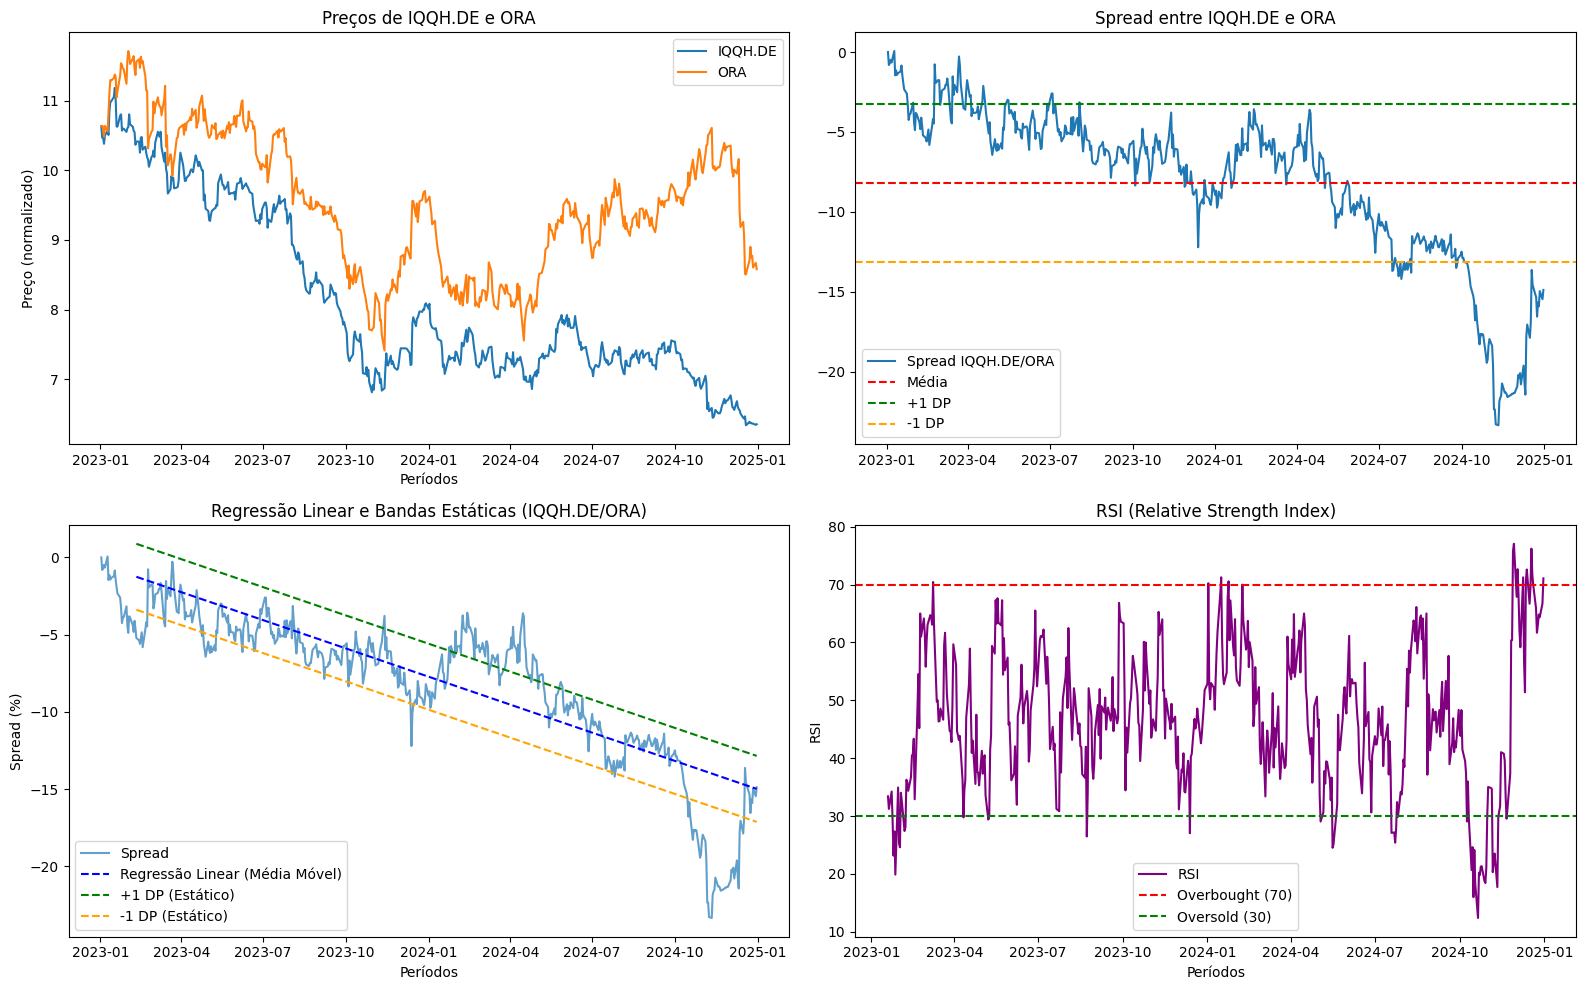

Par: IQQH.DE - ORA | P-Valor ADF: 0.5329
NOT Stationary.

Correlation between IQQH.DE and ORA: 0.78

Cointegration Test Statistic: -1.87
P-Value: 0.59534
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and ORA is NOT cointegrated (p-value >= 0.05).


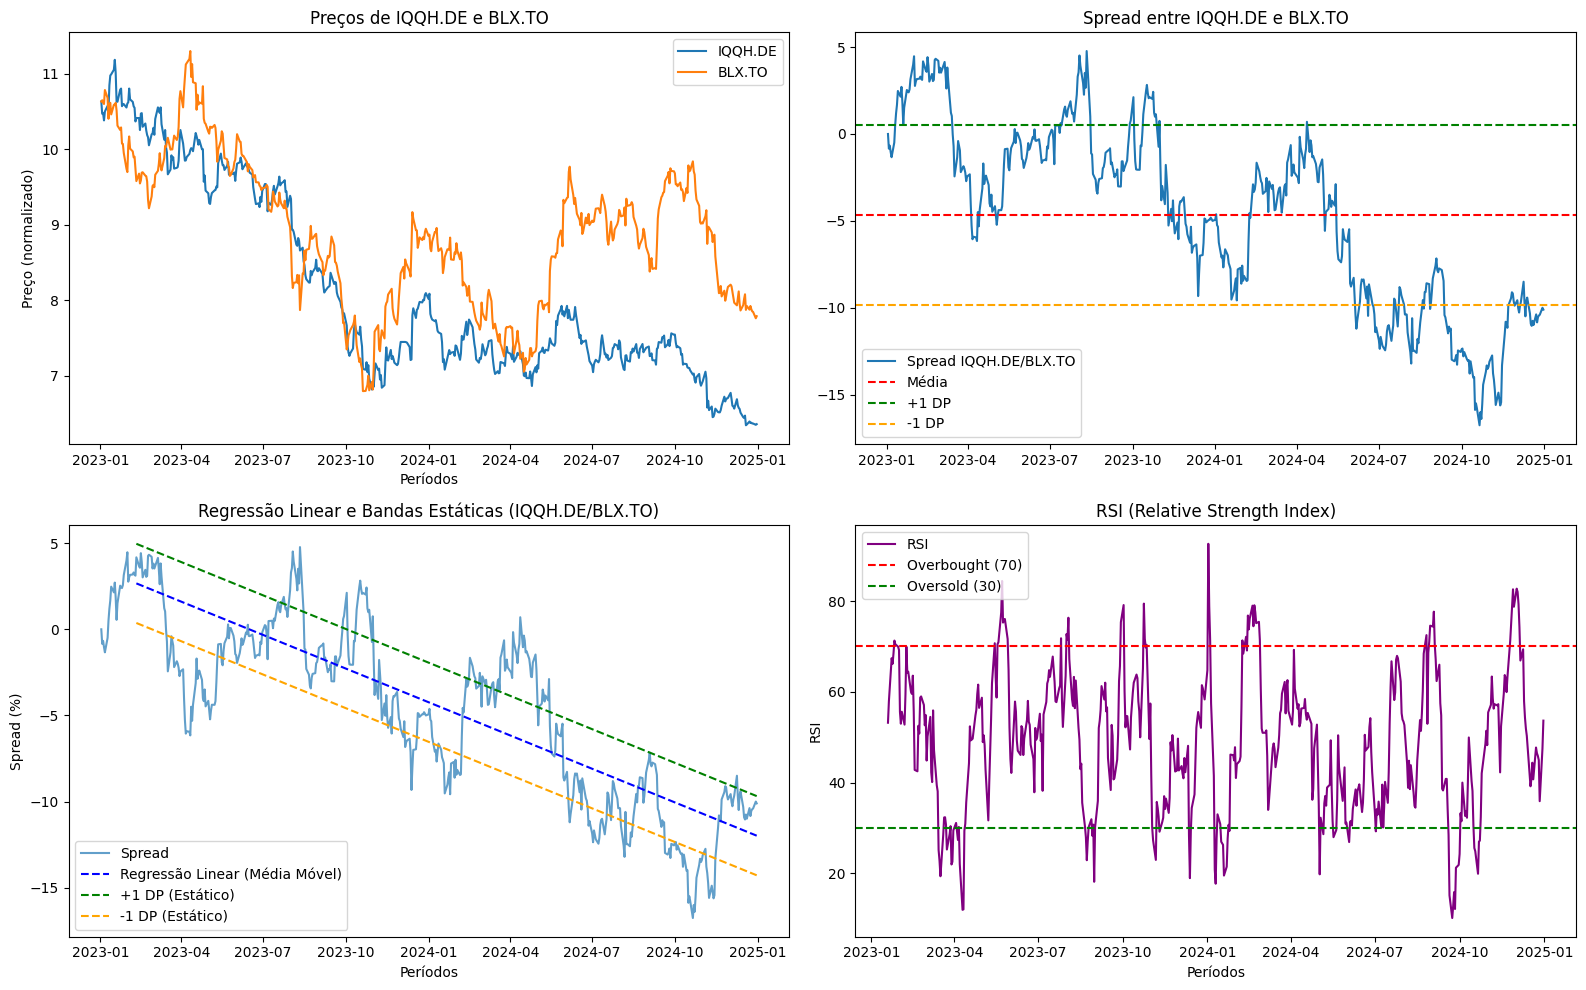

Par: IQQH.DE - BLX.TO | P-Valor ADF: 0.3678
NOT Stationary.

Correlation between IQQH.DE and BLX.TO: 0.74

Cointegration Test Statistic: -1.92
P-Value: 0.56779
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and BLX.TO is NOT cointegrated (p-value >= 0.05).


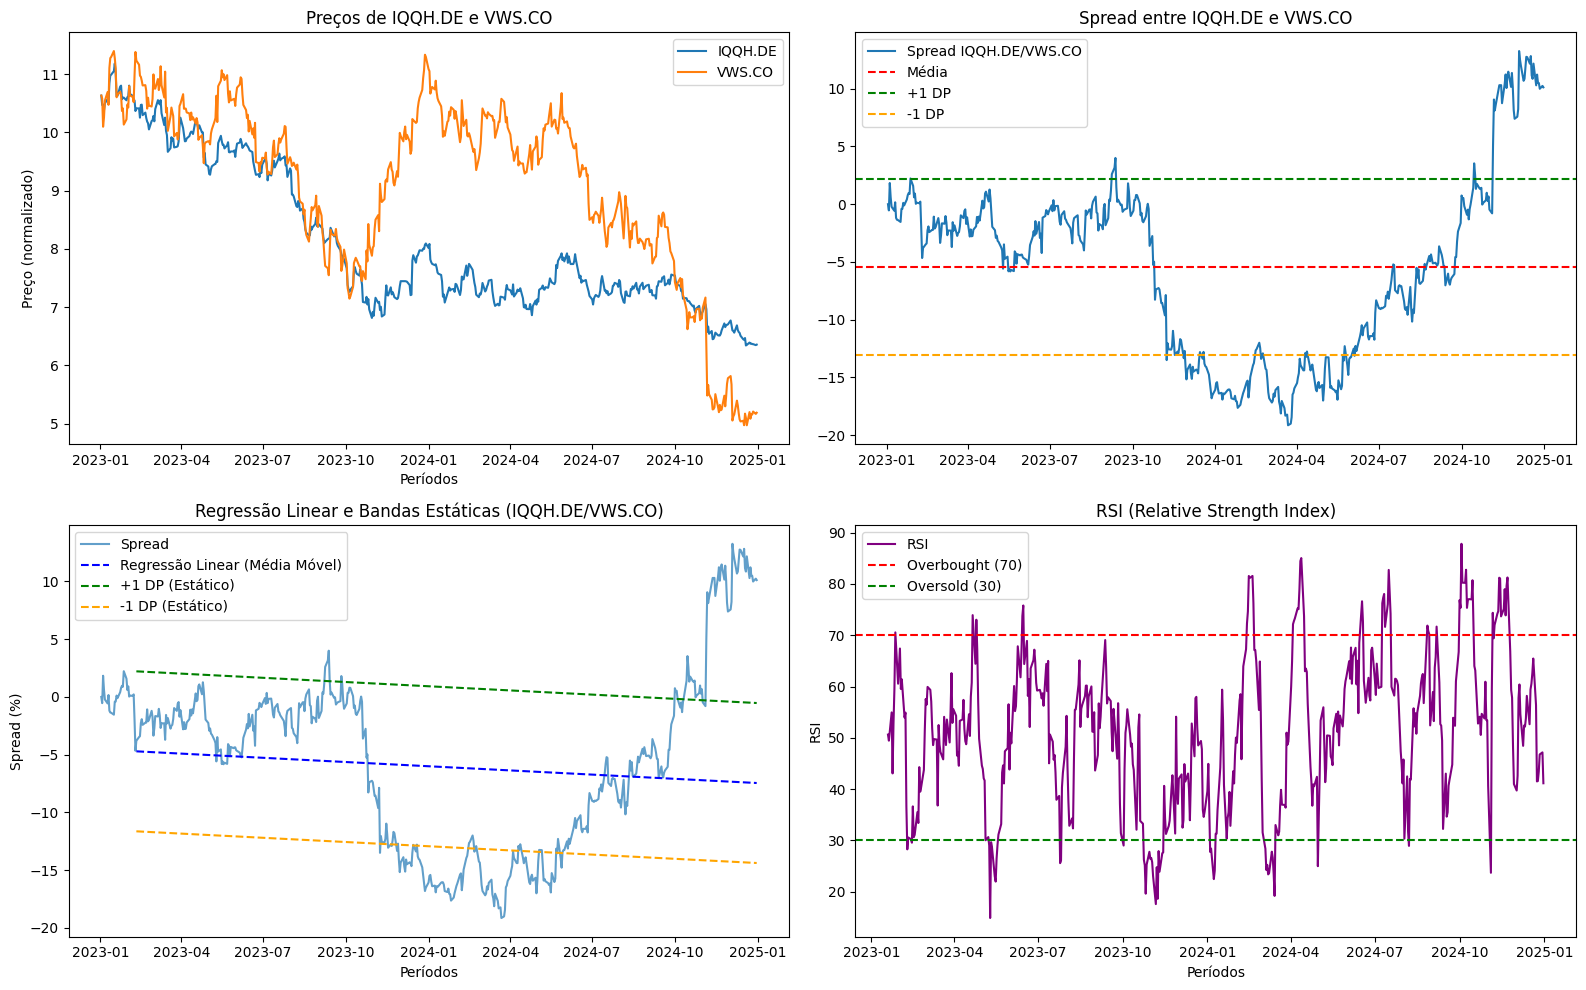

Par: IQQH.DE - VWS.CO | P-Valor ADF: 0.8535
NOT Stationary.

Correlation between IQQH.DE and VWS.CO: 0.63

Cointegration Test Statistic: -1.65
P-Value: 0.69852
Critical Values: [-3.91758444 -3.34788278 -3.05260052]
The pair IQQH.DE and VWS.CO is NOT cointegrated (p-value >= 0.05).


In [1289]:
from sklearn.linear_model import LinearRegression

def test_spread(pair,returns):
    stock1, stock2 = pair

    data = returns[[stock1, stock2]]
    # Normalization and spread
    initial_scale = data[stock1].iloc[0] / data[stock2].iloc[0]
    stock2_scaled = data[stock2] * initial_scale

    spread = ((data[stock1] - stock2_scaled) / (data[stock1] + stock2_scaled)) * 100

    # Calculate moving average of the spread
    spread_ma = spread.rolling(window=30).mean()  # 30-period moving average

    # Perform linear regression on the moving average
    valid_indices = spread_ma.dropna().index
    X = (valid_indices - valid_indices[0]).days.values.reshape(-1, 1)  # Convert dates to numeric values
    y = spread_ma.dropna().values.reshape(-1, 1)

    model = LinearRegression()
    model.fit(X, y)
    regression_line = model.predict(X)

    # Calculate static standard deviation of residuals
    residuals = y.flatten() - regression_line.flatten()
    static_std = np.std(residuals)

    # Add static +1 and -1 standard deviation to the regression line
    upper_band = regression_line.flatten() + static_std
    lower_band = regression_line.flatten() - static_std

    rsi_values = rsi(spread)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Gráfico 2: Preços normalizados das ações
    ax1 = axes[0, 0]
    ax1.plot(data[stock1], label=stock1)
    ax1.plot(stock2_scaled, label=stock2)
    ax1.set_title(f"Preços de {stock1} e {stock2}")
    ax1.set_xlabel("Períodos")
    ax1.set_ylabel("Preço (normalizado)")
    ax1.legend()
    
    # Gráfico 1: Spread com desvios-padrão
    ax2 = axes[0, 1]
    ax2.plot(spread, label=f'Spread {stock1}/{stock2}')
    ax2.axhline(spread.mean(), color='red', linestyle='--', label='Média')
    ax2.axhline(spread.mean() + spread.std(), color='green', linestyle='--', label='+1 DP')
    ax2.axhline(spread.mean() - spread.std(), color='orange', linestyle='--', label='-1 DP')
    ax2.legend()
    ax2.set_title(f'Spread entre {stock1} e {stock2}')

    # Gráfico 3: Regressão linear na média móvel com bandas de desvio padrão estático
    ax3 = axes[1, 0]
    ax3.plot(spread, label='Spread', alpha=0.7)
    ax3.plot(valid_indices, regression_line, label='Regressão Linear (Média Móvel)', color='blue', linestyle='--')
    ax3.plot(valid_indices, upper_band, label='+1 DP (Estático)', color='green', linestyle='--')
    ax3.plot(valid_indices, lower_band, label='-1 DP (Estático)', color='orange', linestyle='--')
    ax3.set_title(f"Regressão Linear e Bandas Estáticas ({stock1}/{stock2})")
    ax3.set_xlabel("Períodos")
    ax3.set_ylabel("Spread (%)")
    ax3.legend()

    # Gráfico 4: RSI
    ax4 = axes[1, 1]
    ax4.plot(rsi_values, label='RSI', color='purple')
    ax4.axhline(70, color='red', linestyle='--', label='Overbought (70)')
    ax4.axhline(30, color='green', linestyle='--', label='Oversold (30)')
    ax4.set_title("RSI (Relative Strength Index)")
    ax4.set_xlabel("Períodos")
    ax4.set_ylabel("RSI")
    ax4.legend()

    plt.tight_layout()  # Ajusta o espaçamento entre os gráficos
    plt.show()

    adf_result = adfuller(spread)
    p_value = adf_result[1]
    
    print(f"Par: {stock1} - {stock2} | P-Valor ADF: {p_value:.4f}")
    if p_value < 0.05:
        print("Stationary.\n")
    else:
        print("NOT Stationary.\n")
    
    correlation = data[stock1].corr(stock2_scaled)
    print(f"Correlation between {stock1} and {stock2}: {correlation:.2f}\n")

    coint_stat, p_value, critical_values = coint(data[stock1], stock2_scaled)

    print(f"Cointegration Test Statistic: {coint_stat:.2f}")
    print(f"P-Value: {p_value:.5f}")
    print("Critical Values:", critical_values)

    # Interpret results
    if p_value < 0.05:
        print(f"The pair {stock1} and {stock2} is cointegrated (p-value < 0.05).")
    else:
        print(f"The pair {stock1} and {stock2} is NOT cointegrated (p-value >= 0.05).")

    
        
spread_f = None
for pair in pairs:
    test_spread(pair,returns)

---
Ao invés da média móvel, foi introduzido uma regressão linear *à média móvel* bem como 1 nível de desvio padrão no Spread do Par. A nossa teoria é que podemos não encontrar um par estacionário mas pode consistentemente subir ou descer retornando não à média mas sim à média móvel aproximada.

---

# Indicadores:
- Média Móvel 👍
    - Mais regressão linear
- RSI 👍
- Oscilador Estocástico
- MACD
- KDJ/Indice Money Flow

In [1290]:
# caminho_excel = r'C:\Users\Utilizador\OneDrive - Universidade de Coimbra\Documentos\Python\MF\ADMF_Projeto\close_prices.xlsx'
# data = pd.read_excel(caminho_excel, index_col='date', parse_dates=True)
# stock1 = 'ENPH Close' 
# stock2 = 'IQQH.DE Close'
# data.dropna(inplace=True)
# initial_scale = data[stock1].iloc[0] / data[stock2].iloc[0]
# stock2_scaled = data[stock2] * initial_scale
# spread = ((data[stock1] - stock2_scaled) / (data[stock1] + stock2_scaled)) * 100
# resultado = pd.DataFrame({
#     stock1: data[stock1],
#     stock2: data[stock2],
#     'Stock2 Scaled': stock2_scaled,
#     'Spread (%)': spread
# })
# print(resultado.head())

In [1291]:
# ('IQQH.DE', 'ENPH') # Colocar o excel a funcionar aqui
s_par = 0
aux = pairs[s_par]
stock2 = aux[0]
stock1 =  aux[1]
# data = yf.download([stock1, stock2], start='2023-01-01', end='2025-03-10')['Close']
# data.dropna(inplace=True)
data = returns[[stock2, stock1]]
initial_scale = data[stock2].iloc[0] / data[stock1].iloc[0]
stock1_scaled = data[stock1] * initial_scale
spread = (((data[stock2] - stock1_scaled) / (data[stock2] + stock1_scaled)) * 100)+100

window = 5

features = pd.DataFrame(index=data.index)
# features['IQQH.DE'] = data[stock2]
# features['ENPH'] = stock1_scaled
features['Spread'] = spread
features['Z-Score'] = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
features['Spread_MA'] = spread.rolling(window).mean()
features['Spread_Std'] = spread.rolling(window).std()
features['RSI'] = rsi(spread)

# 1. Rolling Z-Score
def rolling_zscore(series, window=30):
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    return (series - rolling_mean) / rolling_std

features['rolling_z'] = rolling_zscore(spread)

# 2. Seasonal Decomposition + Z-Score (STL)
def seasonal_zscore(series, period=12):
    res = STL(series, period=period).fit()
    residuals = res.resid
    return zscore(residuals)

features['seasonal_z'] = seasonal_zscore(spread, period=30)

# 3. Differencing + Z-Score
def diff_zscore(series):
    differenced = series.diff()
    return pd.Series(zscore(differenced, nan_policy='omit'), index=series.index)

features['diff_z'] = diff_zscore(spread)

# 4. Modified Z-Score (Robust)
def modified_zscore(series):
    median = np.median(series)
    mad = np.median(np.abs(series - median))
    return (series - median) / (1.4826 * mad)  # 1.4826 para consistência com std

features['mod_z'] = modified_zscore(spread)

# 5. EWMA Z-Score
def ewma_zscore(series, alpha=0.3):
    ewma_mean = series.ewm(alpha=alpha).mean()
    ewma_std = series.ewm(alpha=alpha).std()
    return (series - ewma_mean) / ewma_std

features['ewma_z'] = ewma_zscore(spread)
features.dropna(inplace=True)
features.head(5)

,Spread,Z-Score,Spread_MA,Spread_Std,RSI,rolling_z,seasonal_z,diff_z,mod_z,ewma_z
Date,,,,,,,,,,
2023-02-10,107.660710,0.759071,106.656699,1.322683,56.683319,0.950514,-0.236943,-0.293333,-2.084011,0.537118
2023-02-13,107.543643,0.457635,106.930685,1.339404,49.039401,0.858086,0.553818,-0.126481,-2.103523,0.357624
2023-02-14,107.775996,0.465590,107.548135,0.489403,45.589106,0.913264,0.683769,0.107369,-2.064795,0.454254
2023-02-15,106.598837,-1.690049,107.521254,0.545793,38.188192,0.383842,0.510008,-0.835954,-2.260999,-0.595050
2023-02-16,110.185008,1.675442,107.952839,1.332287,53.863987,1.904313,1.255296,2.351932,-1.663271,1.252156


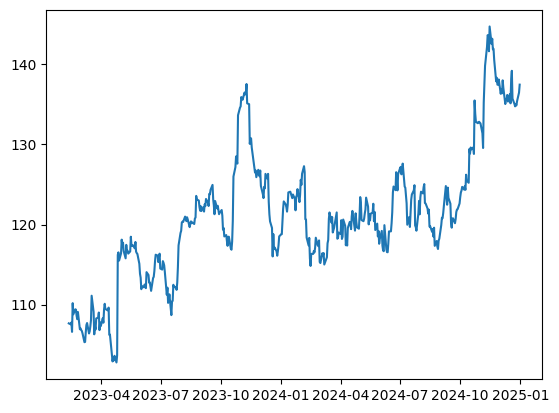

In [1292]:
plt.plot(features['Spread'])
# plt.plot(features['Z-Score'])
# plt.plot(features['Spread_MA'])
# plt.plot(features['rolling_z'])
# plt.plot(features['seasonal_z'])
# plt.plot(features['diff_z'])
# plt.plot(features['mod_z'])
# plt.plot(features['ewma_z'])
# plt.plot(features['RSI'])

Trade_Signal
2    208
1    140
0     78
3     67
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.81      0.75      0.78        28
           2       0.70      0.88      0.78        42
           3       0.75      0.23      0.35        13

    accuracy                           0.76        99
   macro avg       0.78      0.68      0.70        99
weighted avg       0.76      0.76      0.74        99



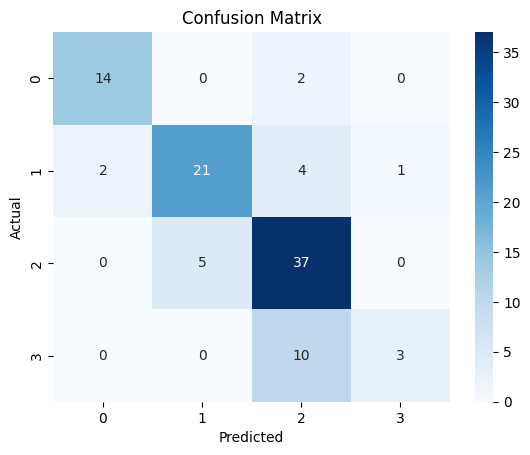

In [1293]:
aux = 1

if aux == 1:
    def calculate_regression_bands(series, window=30):
        valid_data = series.dropna()
        X = (valid_data.index - valid_data.index[0]).days.values.reshape(-1, 1)
        y = valid_data.values.reshape(-1, 1)
        
        model = LinearRegression()
        model.fit(X, y)
        regression_line = model.predict(X)
        regression_line = regression_line.flatten()
        residuals = y.flatten() - regression_line.flatten()
        static_std = np.std(residuals)
        
        upper_band = regression_line.flatten() + static_std
        lower_band = regression_line.flatten() - static_std
        
        return pd.Series(upper_band, index=valid_data.index), pd.Series(lower_band, index=valid_data.index), pd.Series(regression_line, index=valid_data.index)

    # Calcular bandas para toda a série
    upper_band, lower_band, regression_line = calculate_regression_bands(features['Spread_MA'])

    # Função simplificada para classificação
    def label_trades(row):
        if row.name not in upper_band.index:  # Ignorar dados sem banda calculada
            return 4
        
        spread = row['Spread']
        ub = upper_band[row.name]
        lb = lower_band[row.name]
        current_regression = regression_line[row.name]
        
        if spread > ub:
            return 0  # Short Trade
        elif spread < lb:
            return 3   # Long Trade
        elif current_regression <= spread <= ub:
            return 1  # Slightly Bullish
        elif lb <= spread <= current_regression:
            return 2  # Slightly Bearish
        return 4  # Hold

 
    features['Trade_Signal'] = features.apply(label_trades, axis=1)
    print(features['Trade_Signal'].value_counts())

    X = features.drop(columns=['Trade_Signal']).dropna()
    y = features['Trade_Signal'].loc[X.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf_model = RandomForestClassifier(n_estimators=1000, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Trade_Signal
1    196
2    167
0     71
3     59
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       1.00      0.95      0.97        39
           2       1.00      1.00      1.00        34
           3       1.00      1.00      1.00        12

    accuracy                           0.98        99
   macro avg       0.97      0.99      0.98        99
weighted avg       0.98      0.98      0.98        99



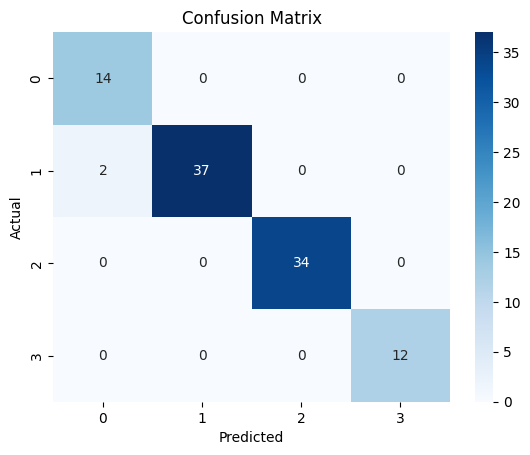

In [1294]:
aux = 2

if aux == 2:
    def label_trades(row):
        mean_spread = spread.mean()  
        std_spread = spread.std() 
        upper_threshold = mean_spread + std_spread#features['Upper_Band_G']
        lower_threshold = mean_spread - std_spread#features['Lower_Band_G']
        
        if row['Spread'] > upper_threshold:
            return 0  # Short Trade
        elif row['Spread'] < lower_threshold:
            return 3   # Long Trade
        elif mean_spread <= row['Spread'] <= upper_threshold:
            return 1  # Slightly Bullish
        elif lower_threshold <= row['Spread'] <= mean_spread:
            return 2  # Slightly Bearish
        return 4  # Hold

    features['Trade_Signal'] = features.apply(label_trades, axis=1)
    print(features['Trade_Signal'].value_counts())

    # Restante do código permanece igual
    X = features.drop(columns=['Trade_Signal']).dropna()
    y = features['Trade_Signal'].loc[X.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    rf_model = RandomForestClassifier(n_estimators=1000, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Trade_Signal
2    126
1    113
4    109
0     85
3     60
Name: count, dtype: int64
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        17
           1       1.00      0.91      0.95        23
           2       0.96      0.96      0.96        25
           3       1.00      1.00      1.00        12
           4       0.92      1.00      0.96        22

    accuracy                           0.96        99
   macro avg       0.96      0.96      0.96        99
weighted avg       0.96      0.96      0.96        99



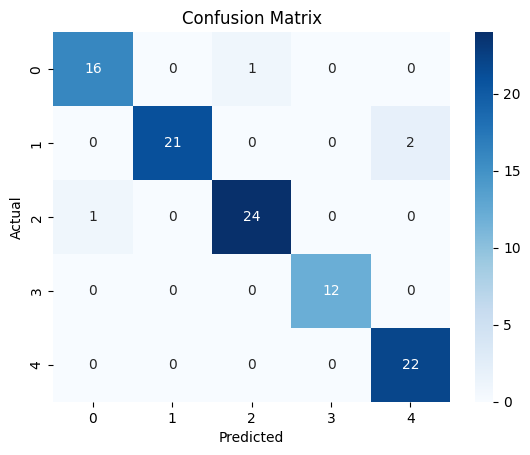

In [1295]:
aux = 3

if aux == 3:
    overbought = 70
    oversold = 30

    def label_trades(row):
        if pd.isna(row['RSI']):
            return 4
        
        rsi_value = row['RSI']
        
        if rsi_value > overbought:
            return 0  # Short Trade
        elif rsi_value < oversold:
            return 3   # Long Trade
        elif (rsi_value <= overbought) and (rsi_value > (overbought - 15)):  # Ex: 55-70
            return 2  # Slightly Bearish
        elif (rsi_value >= oversold) and (rsi_value < (oversold + 15)):  # Ex: 30-45
            return 1  # Slightly Bullish
        else:
            return 4  # Hold

    features['Trade_Signal'] = features.apply(label_trades, axis=1)

    print(features['Trade_Signal'].value_counts())

    X = features.drop(columns=['Trade_Signal']).dropna()
    y = features['Trade_Signal'].loc[X.index]


    # Opção B: Filtrar classes com menos de 2 amostras
    valid_classes = y.value_counts()[y.value_counts() > 1].index
    if len(valid_classes) < 1:
        raise ValueError("Nenhuma classe tem amostras suficientes para estratificação.")

    y_filtered = y[y.isin(valid_classes)]
    X_filtered = X.loc[y_filtered.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
    )

    rf_model = RandomForestClassifier(n_estimators=1000, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [1296]:
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")
print("Checking for overlaps:", X_train.index.intersection(X_test.index))

Training set size: 394, Test set size: 99
Checking for overlaps: DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)


In [1297]:
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=5, random_state=42)
rf_model

RandomForestClassifier(max_depth=5, n_estimators=1000, random_state=42)

In [1298]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=1000, random_state=42)

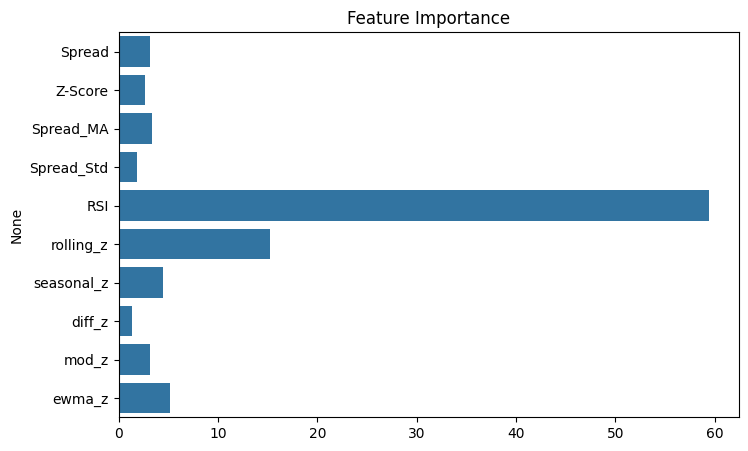

In [1299]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances*100, y=feature_names)
plt.title("Feature Importance")
plt.show()

In [1300]:
# Split Data --> last 20% of the dataset 
features_test = features.copy()
features_test = features_test.sort_index()

# Define split index (last 20% of the dataset)
split_idx = int(len(features_test) * 0.8)

X_train, X_test = features_test.iloc[:split_idx].drop(columns=['Trade_Signal']), features_test.iloc[split_idx:].drop(columns=['Trade_Signal'])
y_train, y_test = features_test.iloc[:split_idx]['Trade_Signal'], features_test.iloc[split_idx:]['Trade_Signal']

# Print sizes to confirm
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

Training set size: 394, Test set size: 99


In [1301]:
rf_model = RandomForestClassifier(n_estimators=1000, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90        26
           1       0.95      1.00      0.97        18
           2       1.00      0.73      0.84        22
           3       1.00      1.00      1.00        12
           4       1.00      0.95      0.98        21

    accuracy                           0.93        99
   macro avg       0.95      0.94      0.94        99
weighted avg       0.94      0.93      0.93        99



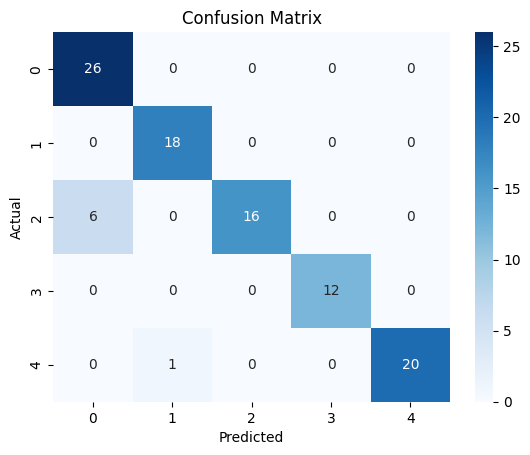

In [1302]:
# Model Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [1303]:
n = 30  # Período do ATR

# Passo 1: Calcular o TR aproximado
features['TR'] = abs(features['Spread'].diff())

# Passo 2: Inicializar a coluna ATR
features['ATR'] = pd.NA  # Usar pd.NA para manter tipos de dados originais

# Passo 3: Calcular o primeiro ATR (média dos primeiros n TRs válidos)
start_idx = 1  # Ignorar o primeiro NaN do .diff()
end_idx = start_idx + n  # Posição final (exclusivo)

# Usar .iloc para acessar por posição, não por índice
if len(features) >= end_idx:
    initial_atr = features['TR'].iloc[start_idx:end_idx].mean()
    features.iloc[end_idx - 1, features.columns.get_loc('ATR')] = initial_atr  # Atribuir via iloc

    # Passo 4: Calcular ATR para os períodos restantes
    for i in range(end_idx, len(features)):
        current_idx = features.index[i]  # Índice real do DataFrame
        previous_idx = features.index[i - 1]
        
        atr_prev = features.at[previous_idx, 'ATR']
        tr_current = features.at[current_idx, 'TR']
        
        features.at[current_idx, 'ATR'] = (atr_prev * (n - 1) + tr_current) / n

features['ATR'] = features['ATR'].ffill()
mean_atr = features['ATR'].mean()
leading_nans = features['ATR'].isna().cumprod().astype(bool)
features.loc[leading_nans, 'ATR'] = mean_atr
features['stopLoss_short'] = features['Spread'].rolling(window=30).max() -  features['ATR']
features['stopLoss_long'] = features['Spread'].rolling(window=30).min() +  features['ATR']
features['stopLoss_long'] = features['stopLoss_long'].fillna(features['stopLoss_long'][30])
features['stopLoss_short'] = features['stopLoss_short'].fillna(features['stopLoss_short'][30])
features['stopLoss_short']

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_18036\3622110118.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features['stopLoss_long'] = features['stopLoss_long'].fillna(features['stopLoss_long'][30])
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_18036\3622110118.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features['stopLoss_long'] = features['stopLoss_long'].fillna(features['stopLoss_long'][30])
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_18036\3622110118.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, 

Date
2023-02-10    110.132892
2023-02-13    110.132892
2023-02-14    110.132892
2023-02-15    110.132892
2023-02-16    110.132892
                 ...    
2024-12-25    143.546519
2024-12-26    143.580474
2024-12-27    142.071115
2024-12-30    142.073190
2024-12-31    140.817307
Name: stopLoss_short, Length: 493, dtype: float64

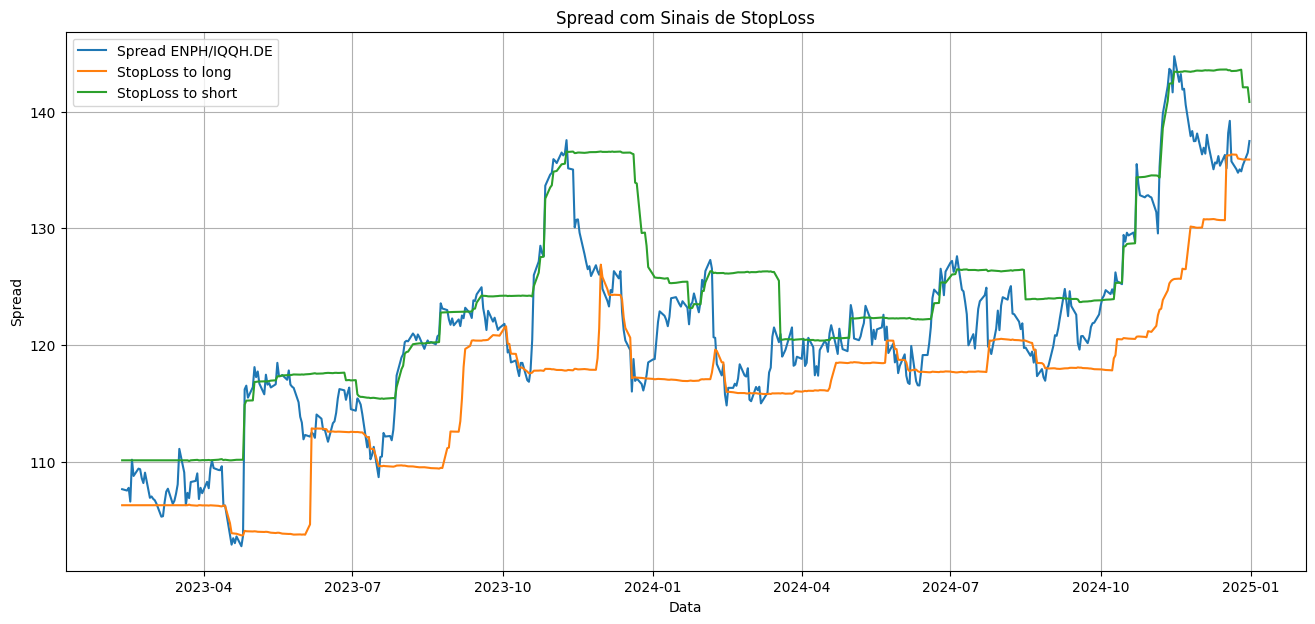

In [1304]:
plt.figure(figsize=(16, 7))
plt.plot(features['Spread'], label=f'Spread {stock1}/{stock2}')
plt.plot(features['stopLoss_long'], label=f'StopLoss to long')
plt.plot(features['stopLoss_short'], label=f'StopLoss to short')
plt.title("Spread com Sinais de StopLoss")
plt.legend()
plt.xlabel("Data")
plt.ylabel("Spread")
plt.grid(True)
plt.show()


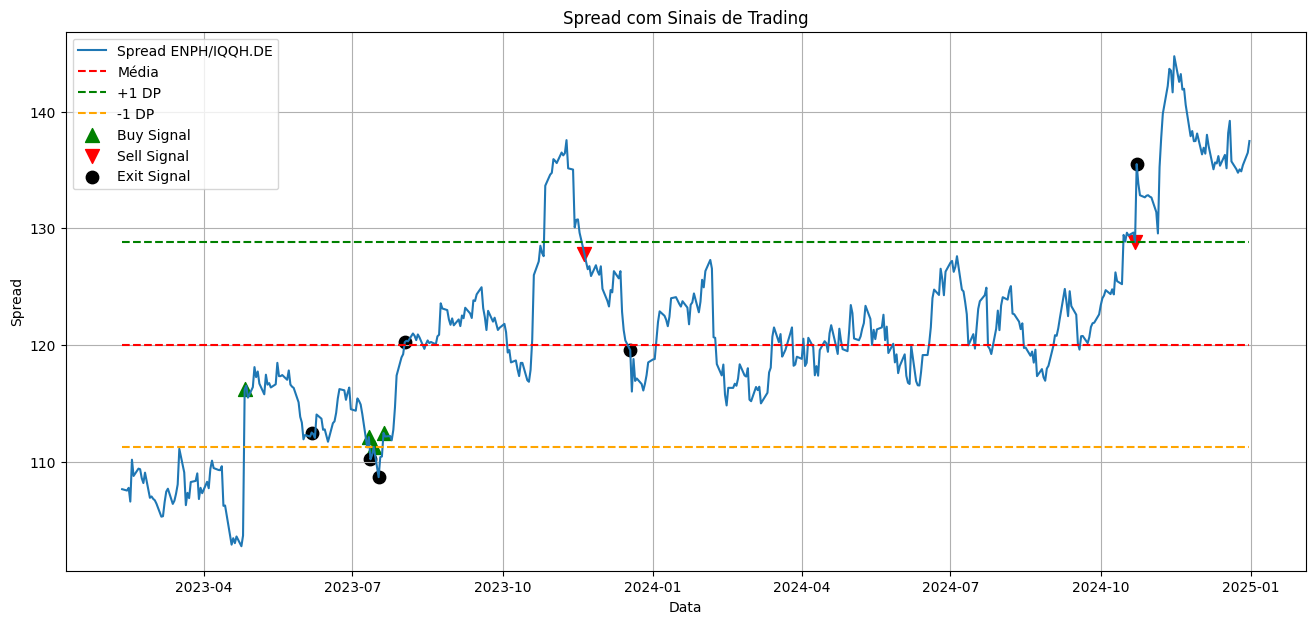

In [1305]:
features['long'] = False
features['short'] = False
features['exit'] = False
position = 0

mean_spread = spread.mean()  
std_spread = spread.std()  

upper_band = mean_spread + std_spread
lower_band = mean_spread - std_spread

features['Spread_MA_G'] = np.full(len(features), mean_spread)
features['Spread_Std_G'] = np.full(len(features), std_spread)
features['Upper_Band_G'] = np.full(len(features), upper_band)
features['Lower_Band_G'] = np.full(len(features), lower_band)

entry_spread = None

for i in range(1, len(features)):
    current_idx = features.index[i]
    prev_spread = features['Spread'].iloc[i-1]
    current_spread = features['Spread'].iloc[i]
    atr_value = features['ATR'].iloc[i]
    
    current_upper = features['Upper_Band_G'].iloc[i]
    current_lower = features['Lower_Band_G'].iloc[i]
    current_ma = features['Spread_MA_G'].iloc[i]
    
    if position == 0:
        if prev_spread < current_lower and current_spread >= current_lower:
            features.at[current_idx, 'long'] = True
            position = 1
            entry_spread = current_spread
        elif prev_spread > current_upper and current_spread <= current_upper:
            features.at[current_idx, 'short'] = True
            position = -1
            entry_spread = current_spread

    elif position == 1:
        if prev_spread < current_ma and current_spread >= current_ma:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread < features.at[current_idx, 'stopLoss_long']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None

    elif position == -1:
        if prev_spread > current_ma and current_spread <= current_ma:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread > features.at[current_idx, 'stopLoss_short']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None

plt.figure(figsize=(16, 7))
plt.plot(features['Spread'], label=f'Spread {stock1}/{stock2}')
plt.plot(features['Spread_MA_G'], color='red', linestyle='--', label='Média')
plt.plot(features['Upper_Band_G'], color='green', linestyle='--', label='+1 DP')
plt.plot(features['Lower_Band_G'], color='orange', linestyle='--', label='-1 DP')

plt.scatter(features.index[features['long']], features['Spread'][features['long']], 
            marker="^", color="green", label="Buy Signal", s=100)
plt.scatter(features.index[features['short']], features['Spread'][features['short']], 
            marker="v", color="red", label="Sell Signal", s=100)
plt.scatter(features.index[features['exit']], features['Spread'][features['exit']], 
            marker="o", color="black", label="Exit Signal", s=80)

plt.legend()
plt.title("Spread com Sinais de Trading")
plt.xlabel("Data")
plt.ylabel("Spread")
plt.grid(True)
plt.show()

In [1306]:
# Backtesting Simulation
num_stock = [10,20,30,40,50]
final_cap_est = []
for i in num_stock:
    # ================= CONFIGURAÇÕES DO USUÁRIO =================
    num_contracts_stock2 = i  # Quantidade de contratos para stock2 (ex: CDNS)
    num_contracts_stock1 = num_contracts_stock2 / 2  # Mantém a proporção 2:1
    # ============================================================

    # Backtesting Simulation
    capital = 10000  # Capital inicial
    position = 0
    entry_price_stock2 = 0
    entry_price_stock1 = 0
    aux = 1

    for i in range(len(features)):
        date = features.index[i]
        
        if features.at[date, 'long'] and position == 0:
            # Compra/Venda com as variáveis genéricas
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]

            position = 1  # Entra em posição long
            print(f"--> {date} | Long {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}, Short {num_contracts_stock1}x {stock1} at {entry_price_stock1:.2f}")

        elif features.at[date, 'short'] and position == 0:
            # Compra/Venda com as variáveis genéricas
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]

            position = -1  # Entra em posição short
            print(f"--> {date} | Short {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}, Short {num_contracts_stock1}x {stock1} at {entry_price_stock1:.2f}")

        elif features.at[date, 'exit'] and position != 0:
            # Fecha a posição
            exit_price_stock2 = data.at[date, stock2]
            exit_price_stock1 = data.at[date, stock1]

            if position == 1:  # Fechando posição long
                profit_stock2 = (exit_price_stock2 - entry_price_stock2) * num_contracts_stock2
                profit_stock1 = (entry_price_stock1 - exit_price_stock1) * num_contracts_stock1  # Stock1 é vendida
            else:  # Fechando posição short
                profit_stock2 = (entry_price_stock2 - exit_price_stock2) * num_contracts_stock2  # Stock2 foi vendida
                profit_stock1 = (exit_price_stock1 - entry_price_stock1) * num_contracts_stock1

            profit_total = profit_stock2 + profit_stock1
            capital += profit_total
            print(f"{aux}>>> {date} | Fechando posição: {profit_total:.2f} | Capital: {capital:.2f}")
            aux +=1
            position = 0

    print(f"\nCapital Final: {capital:.2f}")
    final_cap_est.append(round(capital,4))

--> 2023-04-26 00:00:00 | Long 10x IQQH.DE at 9.57, Short 5.0x ENPH at 163.83
1>>> 2023-06-06 00:00:00 | Fechando posição: -90.70 | Capital: 9909.30
--> 2023-07-11 00:00:00 | Long 10x IQQH.DE at 9.34, Short 5.0x ENPH at 173.78
2>>> 2023-07-12 00:00:00 | Fechando posição: -43.96 | Capital: 9865.34
--> 2023-07-14 00:00:00 | Long 10x IQQH.DE at 9.40, Short 5.0x ENPH at 177.94
3>>> 2023-07-17 00:00:00 | Fechando posição: -57.57 | Capital: 9807.77
--> 2023-07-20 00:00:00 | Long 10x IQQH.DE at 9.52, Short 5.0x ENPH at 175.92
4>>> 2023-08-02 00:00:00 | Fechando posição: 170.28 | Capital: 9978.06
--> 2023-11-20 00:00:00 | Short 10x IQQH.DE at 7.34, Short 5.0x ENPH at 98.50
5>>> 2023-12-18 00:00:00 | Fechando posição: 123.42 | Capital: 10101.48
--> 2024-10-22 00:00:00 | Short 10x IQQH.DE at 7.03, Short 5.0x ENPH at 92.23
6>>> 2024-10-23 00:00:00 | Fechando posição: -67.93 | Capital: 10033.55

Capital Final: 10033.55
--> 2023-04-26 00:00:00 | Long 20x IQQH.DE at 9.57, Short 10.0x ENPH at 163.83


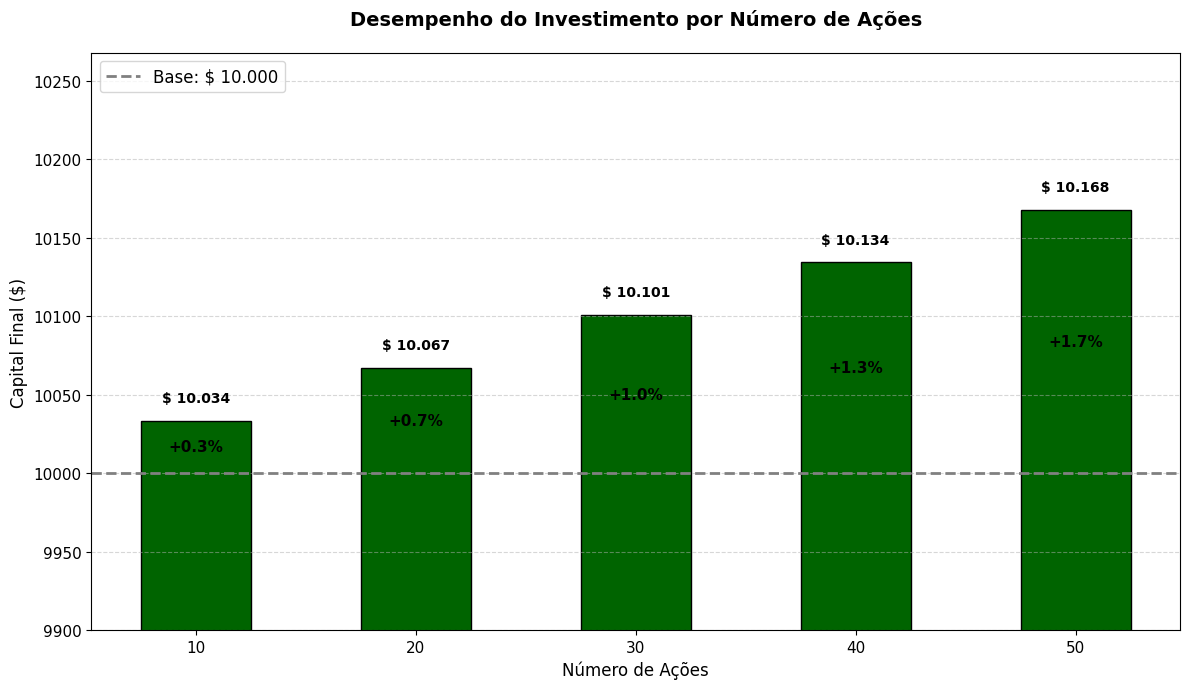

In [1307]:
percent_gain = [(cap - 10000) / 10000 * 100 for cap in final_cap_est]
plt.figure(figsize=(12, 7))
bars = plt.bar(
    num_stock, 
    final_cap_est, 
    width=5,  # Barras mais largas
    color=['DarkGreen' if cap >= 10000 else '#F44336' for cap in final_cap_est],  # Verde/vermelho
    edgecolor='black'
)

# Linha de referência dos 10.000
plt.axhline(
    y=10000, 
    color='Grey', 
    linestyle='--', 
    linewidth=2, 
    label='Base: $ 10.000'
)

# Adicionar valores e porcentagens
for bar, cap, percent in zip(bars, final_cap_est, percent_gain):
    # Valor no topo (formato monetário)
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        cap+10, 
        f'$ {cap:,.0f}'.replace(",", "."),  # Formato brasileiro
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='bold'
    )
    
    # Porcentagem dentro da barra
    y_position = 10000 + (cap - 10000)/2 if cap >= 10000 else cap + 150  # Posicionamento inteligente
    color_text = 'black' if cap >= 10000 else 'black'
    
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        y_position, 
        f'{percent:+.1f}%',  # Sinal explícito
        ha='center', 
        va='center', 
        color=color_text,
        fontsize=11,
        fontweight='bold'
    )

# Ajustes finais
plt.title('Desempenho do Investimento por Número de Ações', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Número de Ações', fontsize=12)
plt.ylabel('Capital Final ($)', fontsize=12)
plt.xticks(num_stock, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(9900, max(final_cap_est) + 100)  # Espaço para os textos
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

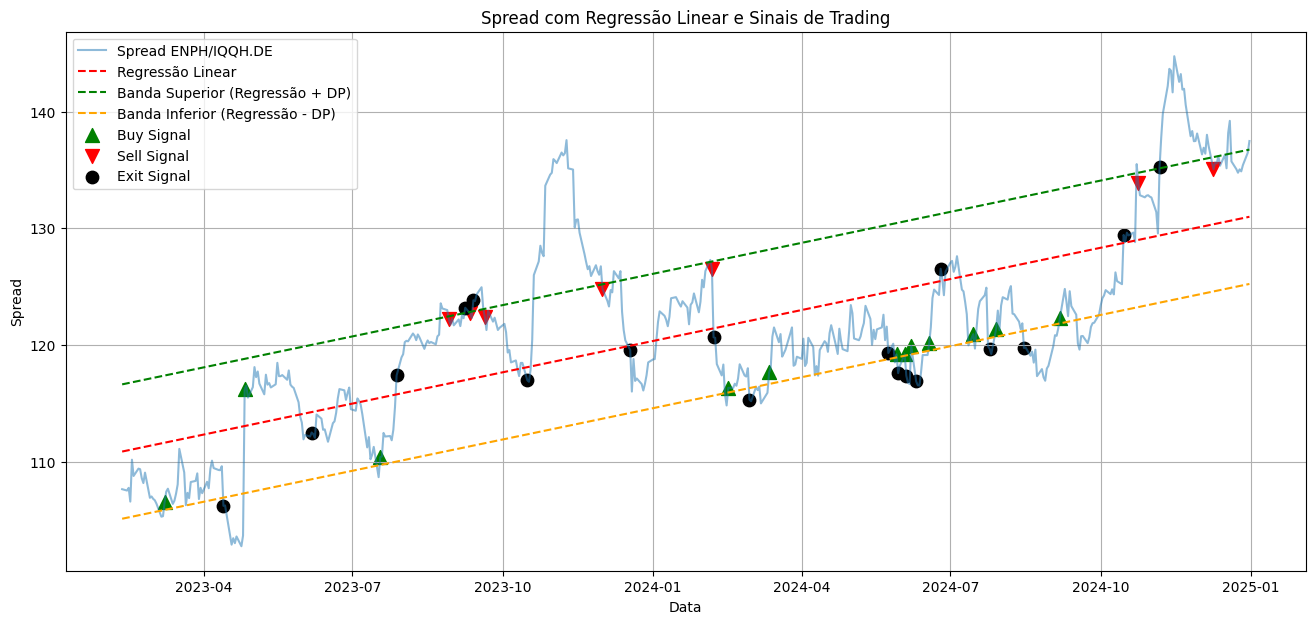

In [1308]:
# Função para calcular bandas de regressão
def calculate_regression_bands(series, window=30):
    valid_data = series.dropna()
    if len(valid_data) < 2:  # Mínimo de dados para regressão
        return pd.Series(), pd.Series(), pd.Series()
    
    X = (valid_data.index - valid_data.index[0]).days.values.reshape(-1, 1)
    y = valid_data.values.reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    regression_line = model.predict(X).flatten()
    residuals = y.flatten() - regression_line
    static_std = np.std(residuals)
    
    upper_band = regression_line + static_std
    lower_band = regression_line - static_std
    
    return (
        pd.Series(upper_band, index=valid_data.index),
        pd.Series(lower_band, index=valid_data.index),
        pd.Series(regression_line, index=valid_data.index)
    )

# Calcular bandas de regressão para o Spread
upper_band, lower_band, regression_line = calculate_regression_bands(features['Spread'])

# Preencher os dados faltantes nas bandas (caso haja NaNs no Spread)
features['Upper_Band_G'] = upper_band.reindex(features.index, method='ffill')
features['Lower_Band_G'] = lower_band.reindex(features.index, method='ffill')
features['Spread_MA_G'] = regression_line.reindex(features.index, method='ffill')

# Função para gerar sinais com base nas bandas de regressão
features['long'] = False
features['short'] = False
features['exit'] = False
position = 0
entry_spread = None

for i in range(1, len(features)):
    current_idx = features.index[i]
    
    # Ignorar datas sem bandas calculadas
    if pd.isna(features.at[current_idx, 'Upper_Band_G']):
        continue
    
    prev_spread = features['Spread'].iloc[i-1]
    current_spread = features['Spread'].iloc[i]
    current_upper = features['Upper_Band_G'].iloc[i]
    current_lower = features['Lower_Band_G'].iloc[i]
    current_ma = features['Spread_MA_G'].iloc[i]
    atr_value = features['ATR'].iloc[i]
    
    if position == 0:
        if prev_spread < current_lower and current_spread >= current_lower:
            features.at[current_idx, 'long'] = True
            position = 1
            entry_spread = current_spread
        elif prev_spread > current_upper and current_spread <= current_upper:
            features.at[current_idx, 'short'] = True
            position = -1
            entry_spread = current_spread
    
    elif position == 1:
        if prev_spread < current_ma and current_spread >= current_ma:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread < features.at[current_idx, 'stopLoss_long']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None
    
    elif position == -1:
        if prev_spread > current_ma and current_spread <= current_ma:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread > features.at[current_idx, 'stopLoss_short']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None


plt.figure(figsize=(16, 7))
plt.plot(features['Spread'], label=f'Spread {stock1}/{stock2}', alpha=0.5)
plt.plot(features['Spread_MA_G'], color='red', linestyle='--', label='Regressão Linear')
plt.plot(features['Upper_Band_G'], color='green', linestyle='--', label='Banda Superior (Regressão + DP)')
plt.plot(features['Lower_Band_G'], color='orange', linestyle='--', label='Banda Inferior (Regressão - DP)')

plt.scatter(features.index[features['long']], features['Spread'][features['long']], 
            marker="^", color="green", label="Buy Signal", s=100)
plt.scatter(features.index[features['short']], features['Spread'][features['short']], 
            marker="v", color="red", label="Sell Signal", s=100)
plt.scatter(features.index[features['exit']], features['Spread'][features['exit']], 
            marker="o", color="black", label="Exit Signal", s=80)

plt.legend()
plt.title("Spread com Regressão Linear e Sinais de Trading")
plt.xlabel("Data")
plt.ylabel("Spread")
plt.grid(True)
plt.show()

In [1309]:
num_stock = [10,20,30,40,50]
final_cap_rl = []
for i in num_stock:
    # Backtesting Simulation
    num_contracts_stock2 = i  # Quantidade de contratos para stock2 (ex: CDNS)
    num_contracts_stock1 = num_contracts_stock2 / 2  # Mantém a proporção 2:1
    capital = 10000
    position = 0
    entry_price_stock2 = 0
    entry_price_stock1 = 0
    aux = 1

    for i in range(len(features)):
        date = features.index[i]
        
        # Ignorar datas sem bandas calculadas
        if pd.isna(features.at[date, 'Upper_Band_G']):
            continue
        
        if features.at[date, 'long'] and position == 0:
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]
            position = 1
            print(f"--> {date} | Long {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}")

        elif features.at[date, 'short'] and position == 0:
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]
            position = -1
            print(f"--> {date} | Short {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}")

        elif features.at[date, 'exit'] and position != 0:
            exit_price_stock2 = data.at[date, stock2]
            exit_price_stock1 = data.at[date, stock1]
            
            if position == 1:
                profit_stock2 = (exit_price_stock2 - entry_price_stock2) * num_contracts_stock2
                profit_stock1 = (entry_price_stock1 - exit_price_stock1) * num_contracts_stock1
            else:
                profit_stock2 = (entry_price_stock2 - exit_price_stock2) * num_contracts_stock2
                profit_stock1 = (exit_price_stock1 - entry_price_stock1) * num_contracts_stock1
            
            profit_total = profit_stock2 + profit_stock1
            capital += profit_total
            print(f"{aux}>>> {date} | Fechando posição: {profit_total:.2f} | Capital: {capital:.2f}")
            aux +=1
            position = 0

    print(f"\nCapital Final: {capital:.2f}")
    final_cap_rl.append(round(capital,4))

--> 2023-03-08 00:00:00 | Long 10x IQQH.DE at 10.48
1>>> 2023-04-13 00:00:00 | Fechando posição: 38.33 | Capital: 10038.33
--> 2023-04-26 00:00:00 | Long 10x IQQH.DE at 9.57
2>>> 2023-06-06 00:00:00 | Fechando posição: -90.70 | Capital: 9947.64
--> 2023-07-18 00:00:00 | Long 10x IQQH.DE at 9.55
3>>> 2023-07-28 00:00:00 | Fechando posição: 145.45 | Capital: 10093.09
--> 2023-08-29 00:00:00 | Short 10x IQQH.DE at 8.53
4>>> 2023-09-08 00:00:00 | Fechando posição: -39.95 | Capital: 10053.14
--> 2023-09-11 00:00:00 | Short 10x IQQH.DE at 8.17
5>>> 2023-09-13 00:00:00 | Fechando posição: -13.14 | Capital: 10040.00
--> 2023-09-20 00:00:00 | Short 10x IQQH.DE at 8.23
6>>> 2023-10-16 00:00:00 | Fechando posição: 22.60 | Capital: 10062.60
--> 2023-12-01 00:00:00 | Short 10x IQQH.DE at 7.45
7>>> 2023-12-18 00:00:00 | Fechando posição: 84.38 | Capital: 10146.98
--> 2024-02-06 00:00:00 | Short 10x IQQH.DE at 7.29
8>>> 2024-02-07 00:00:00 | Fechando posição: 82.65 | Capital: 10229.63
--> 2024-02-16 

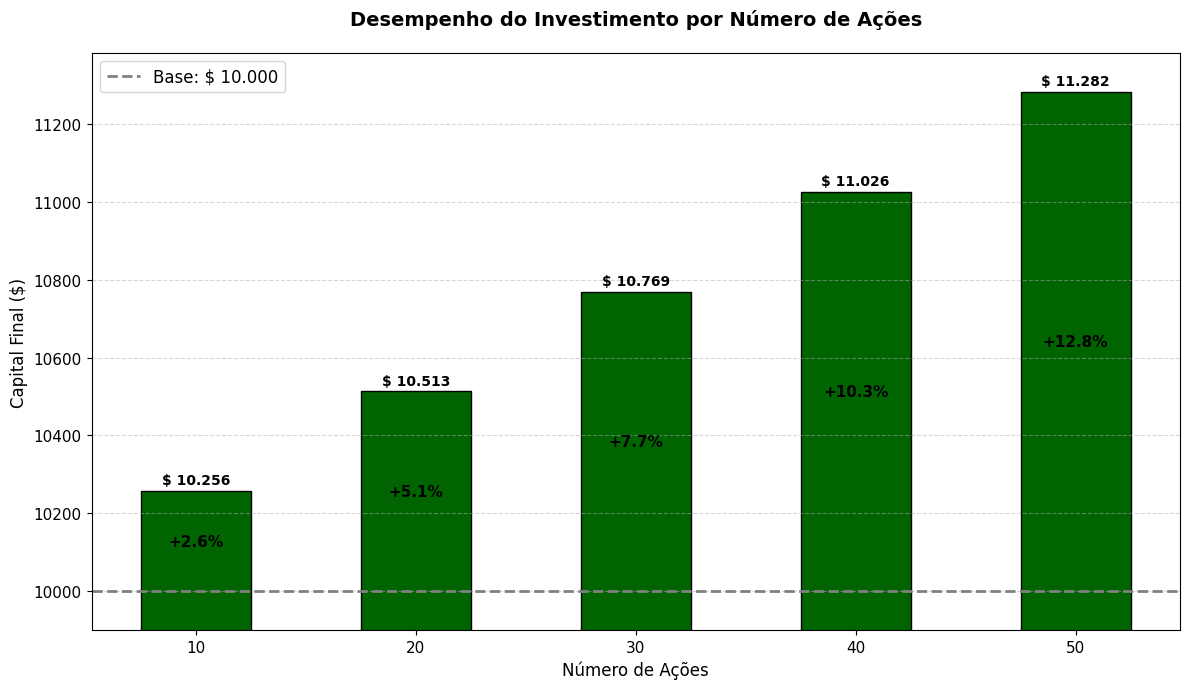

In [1310]:
percent_gain = [(cap - 10000) / 10000 * 100 for cap in final_cap_rl]
plt.figure(figsize=(12, 7))
bars = plt.bar(
    num_stock, 
    final_cap_rl, 
    width=5,  # Barras mais largas
    color=['DarkGreen' if cap >= 10000 else '#F44336' for cap in final_cap_rl],  # Verde/vermelho
    edgecolor='black'
)

# Linha de referência dos 10.000
plt.axhline(
    y=10000, 
    color='Grey', 
    linestyle='--', 
    linewidth=2, 
    label='Base: $ 10.000'
)

# Adicionar valores e porcentagens
for bar, cap, percent in zip(bars, final_cap_rl, percent_gain):
    # Valor no topo (formato monetário)
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        cap+10, 
        f'$ {cap:,.0f}'.replace(",", "."),  # Formato brasileiro
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='bold'
    )
    
    # Porcentagem dentro da barra
    y_position = 10000 + (cap - 10000)/2 if cap >= 10000 else cap + 150  # Posicionamento inteligente
    color_text = 'black' if cap >= 10000 else 'black'
    
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        y_position, 
        f'{percent:+.1f}%',  # Sinal explícito
        ha='center', 
        va='center', 
        color=color_text,
        fontsize=11,
        fontweight='bold'
    )

# Ajustes finais
plt.title('Desempenho do Investimento por Número de Ações', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Número de Ações', fontsize=12)
plt.ylabel('Capital Final ($)', fontsize=12)
plt.xticks(num_stock, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(9900, max(final_cap_rl) + 100)  # Espaço para os textos
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

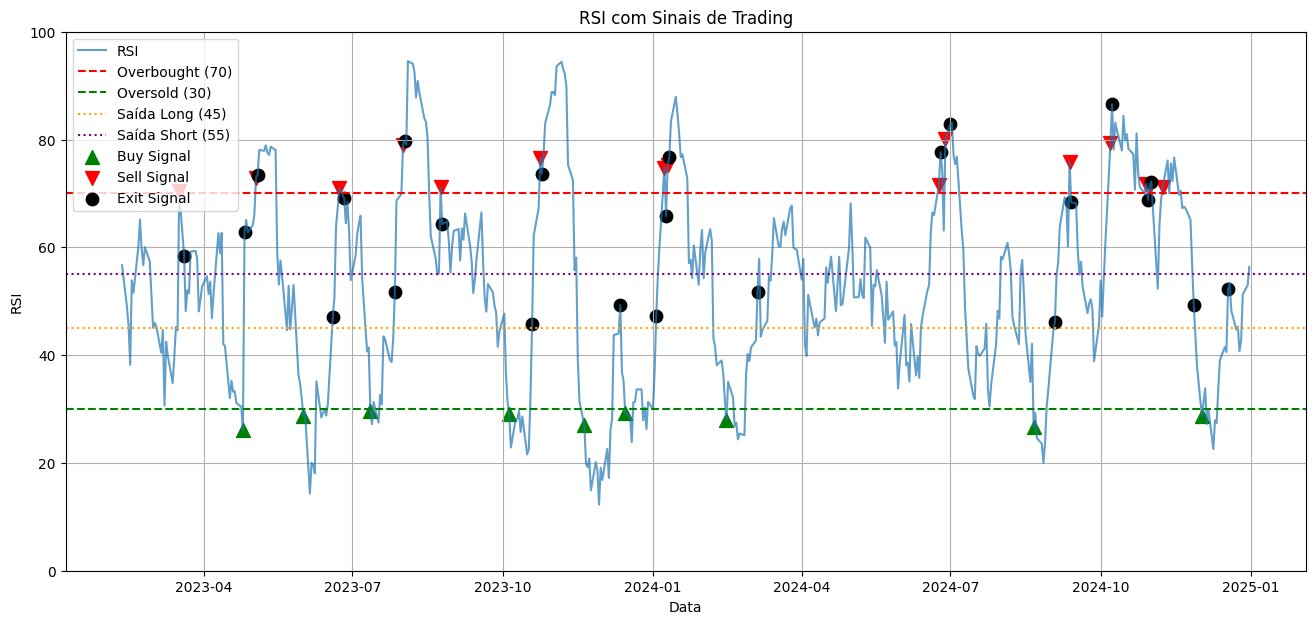

In [1311]:
# Configurações do RSI
overbought = 70
oversold = 30
exit_level_long = 45  # Saída para posições long
exit_level_short = 55  # Saída para posições short

# Inicializar colunas de sinais
features['long'] = False
features['short'] = False
features['exit'] = False
position = 0
entry_spread = None

for i in range(1, len(features)):
    current_idx = features.index[i]
    
    # Ignorar dados sem RSI
    if pd.isna(features.at[current_idx, 'RSI']) or pd.isna(features.at[features.index[i-1], 'RSI']):
        continue
    
    prev_rsi = features['RSI'].iloc[i-1]
    current_rsi = features['RSI'].iloc[i]
    atr_value = features['ATR'].iloc[i]
    
    if position == 0:
        # Entrada Long: RSI cruza para baixo de 30 (oversold)
        if prev_rsi >= oversold and current_rsi < oversold:
            features.at[current_idx, 'long'] = True
            position = 1
            entry_spread = current_spread
        # Entrada Short: RSI cruza para cima de 70 (overbought)
        elif prev_rsi <= overbought and current_rsi > overbought:
            features.at[current_idx, 'short'] = True
            position = -1
            entry_spread = current_spread
    
    elif position == 1:
        # Saída Long: RSI cruza para cima de 45 (zona neutra)
        if prev_rsi < exit_level_long and current_rsi >= exit_level_long:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread < features.at[current_idx, 'stopLoss_long']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None
    
    elif position == -1:
        # Saída Short: RSI cruza para baixo de 55 (zona neutra)
        if prev_rsi > exit_level_short and current_rsi <= exit_level_short:
            features.at[current_idx, 'exit'] = True
            position = 0
        elif current_spread > features.at[current_idx, 'stopLoss_short']:
            features.at[current_idx, 'exit'] = True
            position = 0
            entry_spread = None

plt.figure(figsize=(16, 7))
plt.plot(features['RSI'], label='RSI', alpha=0.7)
plt.axhline(overbought, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(oversold, color='green', linestyle='--', label='Oversold (30)')
plt.axhline(exit_level_long, color='orange', linestyle=':', label='Saída Long (45)')
plt.axhline(exit_level_short, color='purple', linestyle=':', label='Saída Short (55)')

plt.scatter(features.index[features['long']], features['RSI'][features['long']], 
            marker="^", color="green", label="Buy Signal", s=100)
plt.scatter(features.index[features['short']], features['RSI'][features['short']], 
            marker="v", color="red", label="Sell Signal", s=100)
plt.scatter(features.index[features['exit']], features['RSI'][features['exit']], 
            marker="o", color="black", label="Exit Signal", s=80)

plt.legend()
plt.title("RSI com Sinais de Trading")
plt.xlabel("Data")
plt.ylabel("RSI")
plt.ylim(0, 100)
plt.grid(True)
plt.show()

In [1312]:
num_stock = [10,20,30,40,50]
final_cap_rsi = []
for i in num_stock:
    # Backtesting Simulation
    num_contracts_stock2 = i  # Quantidade de contratos para stock2 (ex: CDNS)
    num_contracts_stock1 = num_contracts_stock2 / 2  # Mantém a proporção 2:1
    capital = 10000
    position = 0
    entry_price_stock2 = 0
    entry_price_stock1 = 0
    aux = 1

    for i in range(len(features)):
        date = features.index[i]
        
        # Ignorar datas sem RSI
        if pd.isna(features.at[date, 'RSI']):
            continue
        
        if features.at[date, 'long'] and position == 0:
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]
            position = 1
            print(f"--> {date} | Long {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}")

        elif features.at[date, 'short'] and position == 0:
            entry_price_stock2 = data.at[date, stock2]
            entry_price_stock1 = data.at[date, stock1]
            position = -1
            print(f"--> {date} | Short {num_contracts_stock2}x {stock2} at {entry_price_stock2:.2f}")

        elif features.at[date, 'exit'] and position != 0:
            exit_price_stock2 = data.at[date, stock2]
            exit_price_stock1 = data.at[date, stock1]
            
            if position == 1:
                profit_stock2 = (exit_price_stock2 - entry_price_stock2) * num_contracts_stock2
                profit_stock1 = (entry_price_stock1 - exit_price_stock1) * num_contracts_stock1
            else:
                profit_stock2 = (entry_price_stock2 - exit_price_stock2) * num_contracts_stock2
                profit_stock1 = (exit_price_stock1 - entry_price_stock1) * num_contracts_stock1
            
            profit_total = profit_stock2 + profit_stock1
            capital += profit_total
            print(f"{aux}>>> {date} | Fechando posição: {profit_total:.2f} | Capital: {capital:.2f}")
            aux +=1
            position = 0

    print(f"\nCapital Final: {capital:.2f}")
    final_cap_rsi.append(round(capital,4))

--> 2023-03-17 00:00:00 | Short 10x IQQH.DE at 9.67
1>>> 2023-03-20 00:00:00 | Fechando posição: 43.72 | Capital: 10043.72
--> 2023-04-25 00:00:00 | Long 10x IQQH.DE at 10.00
2>>> 2023-04-26 00:00:00 | Fechando posição: 279.54 | Capital: 10323.26
--> 2023-05-03 00:00:00 | Short 10x IQQH.DE at 9.27
3>>> 2023-05-04 00:00:00 | Fechando posição: -0.93 | Capital: 10322.33
--> 2023-06-01 00:00:00 | Long 10x IQQH.DE at 9.71
4>>> 2023-06-19 00:00:00 | Fechando posição: 28.99 | Capital: 10351.32
--> 2023-06-23 00:00:00 | Short 10x IQQH.DE at 9.27
5>>> 2023-06-26 00:00:00 | Fechando posição: 2.50 | Capital: 10353.82
--> 2023-07-12 00:00:00 | Long 10x IQQH.DE at 9.45
6>>> 2023-07-27 00:00:00 | Fechando posição: 79.89 | Capital: 10433.71
--> 2023-08-01 00:00:00 | Short 10x IQQH.DE at 9.34
7>>> 2023-08-02 00:00:00 | Fechando posição: -44.07 | Capital: 10389.64
--> 2023-08-24 00:00:00 | Short 10x IQQH.DE at 8.33
8>>> 2023-08-25 00:00:00 | Fechando posição: 8.35 | Capital: 10397.99
--> 2023-10-05 00:

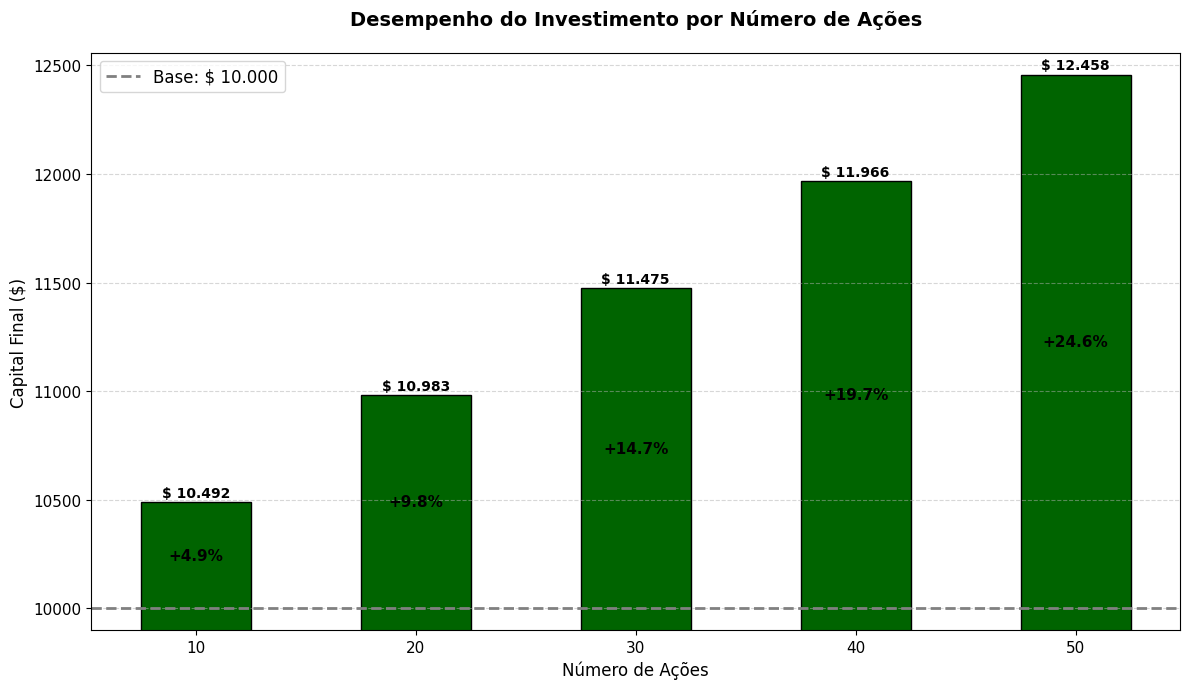

In [1313]:
percent_gain = [(cap - 10000) / 10000 * 100 for cap in final_cap_rsi]
plt.figure(figsize=(12, 7))
bars = plt.bar(
    num_stock, 
    final_cap_rsi, 
    width=5,  # Barras mais largas
    color=['DarkGreen' if cap >= 10000 else '#F44336' for cap in final_cap_rsi],  # Verde/vermelho
    edgecolor='black'
)

# Linha de referência dos 10.000
plt.axhline(
    y=10000, 
    color='Grey', 
    linestyle='--', 
    linewidth=2, 
    label='Base: $ 10.000'
)

# Adicionar valores e porcentagens
for bar, cap, percent in zip(bars, final_cap_rsi, percent_gain):
    # Valor no topo (formato monetário)
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        cap+10, 
        f'$ {cap:,.0f}'.replace(",", "."),  # Formato brasileiro
        ha='center', 
        va='bottom', 
        fontsize=10,
        fontweight='bold'
    )
    
    # Porcentagem dentro da barra
    y_position = 10000 + (cap - 10000)/2 if cap >= 10000 else cap + 150  # Posicionamento inteligente
    color_text = 'black' if cap >= 10000 else 'black'
    
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        y_position, 
        f'{percent:+.1f}%',  # Sinal explícito
        ha='center', 
        va='center', 
        color=color_text,
        fontsize=11,
        fontweight='bold'
    )

# Ajustes finais
plt.title('Desempenho do Investimento por Número de Ações', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Número de Ações', fontsize=12)
plt.ylabel('Capital Final ($)', fontsize=12)
plt.xticks(num_stock, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(9900, max(final_cap_rsi) + 100)  # Espaço para os textos
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [1314]:
import json
from pathlib import Path

# final_stats_entry = {s_par: [final_cap_est, final_cap_rl, final_cap_rsi]}

file_path = Path('final_stats.json')
# if file_path.exists():
#     with open(file_path, 'r') as f:
#         loaded_stats = json.load(f)
# else:
#     loaded_stats = {}

# loaded_stats.update(final_stats_entry)

# with open(file_path, 'w') as f:
#     json.dump(loaded_stats, f, indent=4)
with open(file_path, 'r') as f:
    loaded_stats = json.load(f)

print(loaded_stats)

{'0': [[10033.5478, 10067.0956, 10100.6434, 10134.1912, 10167.739], [10256.4956, 10512.9912, 10769.4868, 11025.9824, 11282.478], [10491.5791, 10983.1581, 11474.7372, 11966.3163, 12457.8953]], '1': [[10011.5627, 10023.1254, 10034.6882, 10046.2509, 10057.8136], [9993.8664, 9987.7329, 9981.5993, 9975.4657, 9969.3321], [10030.8744, 10061.7487, 10092.6231, 10123.4975, 10154.3718]], '2': [[10634.686, 11269.3719, 11904.0579, 12538.7438, 13173.4298], [10943.7389, 11887.4778, 12831.2167, 13774.9556, 14718.6944], [10639.4337, 11278.8674, 11918.3011, 12557.7348, 13197.1685]], '3': [[10074.9544, 10149.9087, 10224.8631, 10299.8175, 10374.7718], [10078.4941, 10156.9882, 10235.4823, 10313.9764, 10392.4705], [10055.096, 10110.192, 10165.288, 10220.384, 10275.48]], '4': [[10017.9746, 10035.9492, 10053.9237, 10071.8983, 10089.8729], [10022.4486, 10044.8973, 10067.3459, 10089.7945, 10112.2432], [10003.341, 10006.6819, 10010.0229, 10013.3638, 10016.7048]], '5': [[10006.0889, 10012.1778, 10018.2667, 10024.

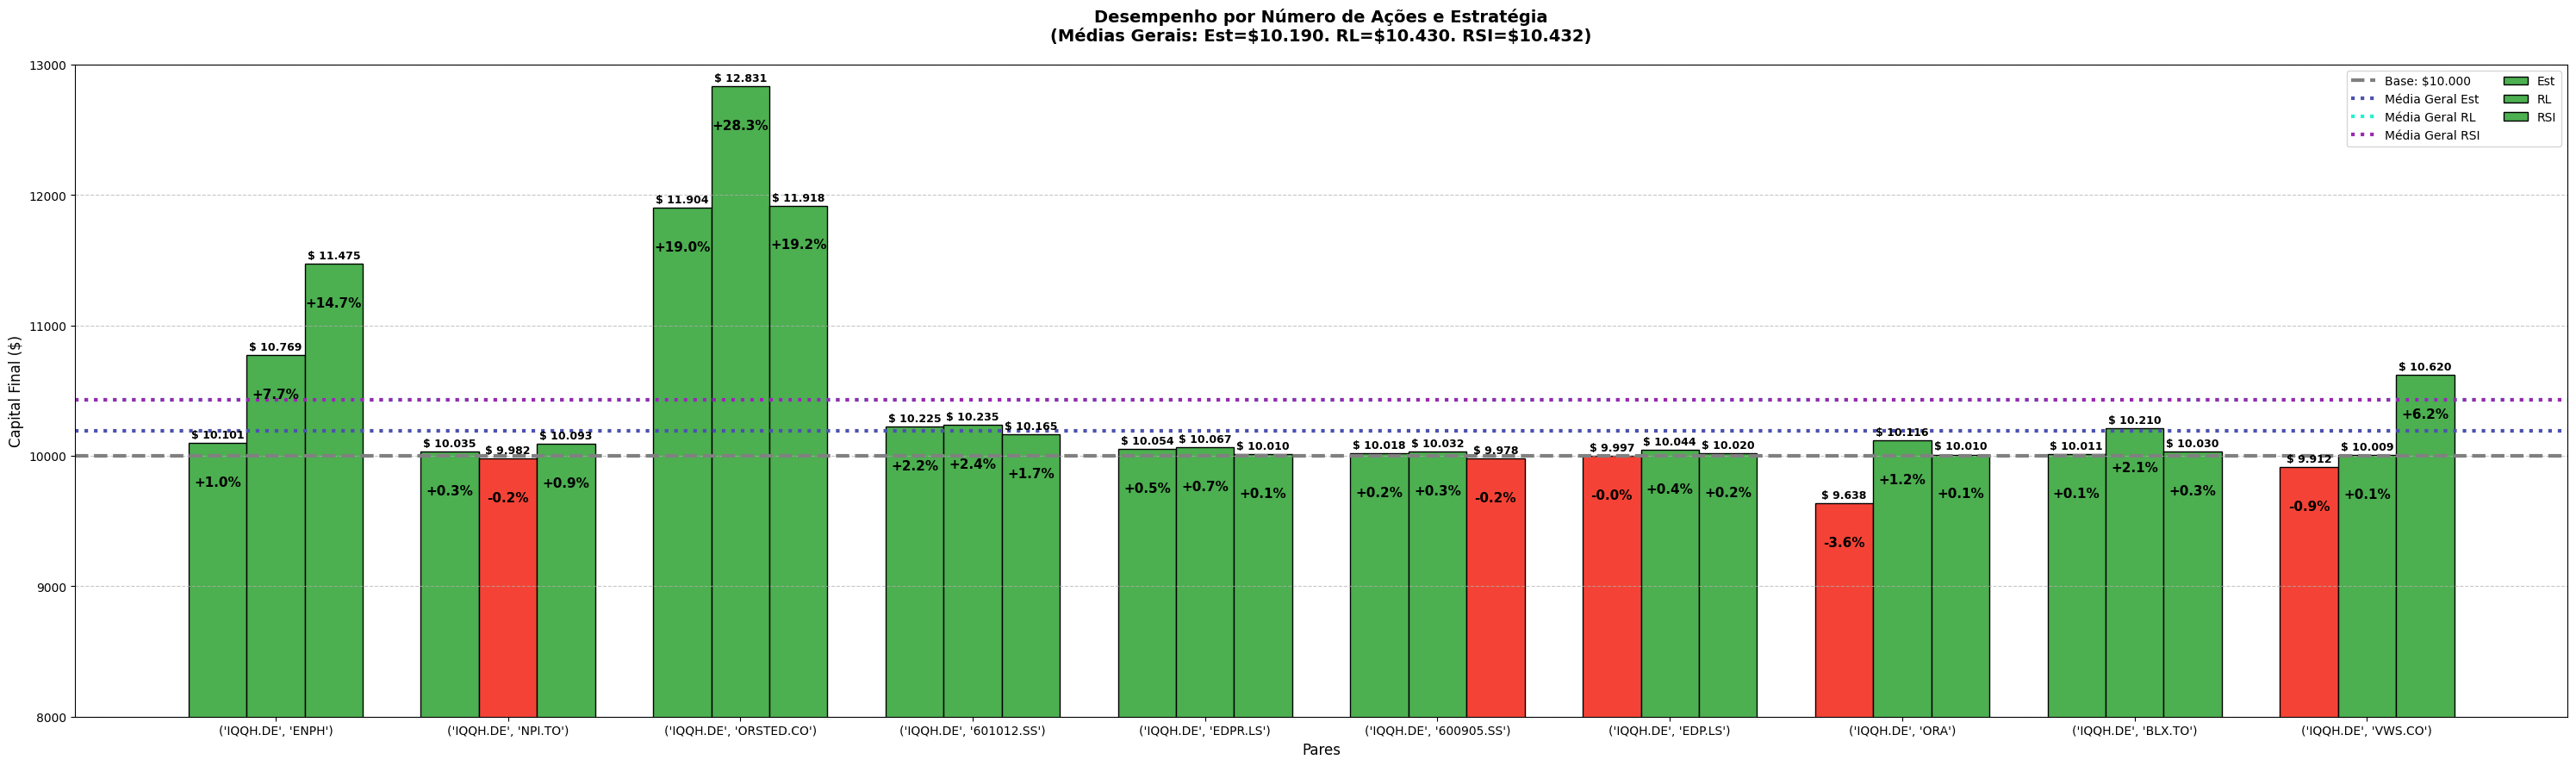

In [1315]:
est_medias = []
rl_medias = []
rsi_medias = []

for key in sorted(loaded_stats.keys(), key=lambda x: int(x)):
    # Médias por categoria
    est_avg = np.mean(loaded_stats[key][0])
    rl_avg = np.mean(loaded_stats[key][1])
    rsi_avg = np.mean(loaded_stats[key][2])
    
    est_medias.append(est_avg)
    rl_medias.append(rl_avg)
    rsi_medias.append(rsi_avg)

# Médias gerais
media_geral_est = np.mean(est_medias)
media_geral_rl = np.mean(rl_medias)
media_geral_rsi = np.mean(rsi_medias)

# Configurações do gráfico
plt.figure(figsize=(30, 9))
x = np.arange(len(loaded_stats))
width = 0.25

# Criar barras agrupadas
bars_est = plt.bar(x - width, est_medias, width, label='Est', 
                  color=['#4CAF50' if v >= 10000 else '#F44336' for v in est_medias], 
                  edgecolor='black')

bars_rl = plt.bar(x, rl_medias, width, label='RL', 
                 color=['#4CAF50' if v >= 10000 else '#F44336' for v in rl_medias], 
                 edgecolor='black')

bars_rsi = plt.bar(x + width, rsi_medias, width, label='RSI', 
                  color=['#4CAF50' if v >= 10000 else '#F44336' for v in rsi_medias], 
                  edgecolor='black')

# Linha de referência e médias gerais
plt.axhline(10000, color='grey', linestyle='--', linewidth=3, label='Base: $10.000')
plt.axhline(media_geral_est, color="#4C51AF", linestyle=':', linewidth=3, label='Média Geral Est')
plt.axhline(media_geral_rl, color="#21F3CD", linestyle=':', linewidth=3, label='Média Geral RL')
plt.axhline(media_geral_rsi, color='#9C27B0', linestyle=':', linewidth=3, label='Média Geral RSI')

# Adicionar valores e porcentagens
for bars, medias in zip([bars_est, bars_rl, bars_rsi], [est_medias, rl_medias, rsi_medias]):
    for bar, valor in zip(bars, medias):
        # Valor no topo
        plt.text(bar.get_x() + bar.get_width()/2, valor + 20, 
                f'$ {valor:,.0f}'.replace(",", "."), 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Porcentagem dentro
        percent = (valor - 10000) / 10000 * 100
        y_pos = valor - 300  # Posicionamento adaptativo
        plt.text(bar.get_x() + bar.get_width()/2, y_pos, 
                f'{percent:+.1f}%', 
                ha='center', va='center', color='black', fontsize=11, fontweight='bold')

# Ajustes finais
plt.title('Desempenho por Número de Ações e Estratégia\n(Médias Gerais: Est=${:,.0f}, RL=${:,.0f}, RSI=${:,.0f})'.format(media_geral_est, media_geral_rl, media_geral_rsi).replace(",", "."), 
         pad=20, fontsize=14, fontweight='bold')
plt.xticks(x, pairs)
plt.xlabel('Pares', fontsize=12)
plt.ylabel('Capital Final ($)', fontsize=12)
plt.ylim(8000, 13000)  # Ajustado para incluir todos os dados
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(ncol=2, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

In [1316]:
def calcular_estatisticas_spread(spread,stock1,stock2, window=20):
    """
    Calcula volatilidade, média de máximos/mínimos e diferença percentual.
    
    Parâmetros:
    - spread: Série temporal do spread (pd.Series).
    - window: Janela de cálculo (padrão: 20).
    - metodo: "std" (desvio padrão) ou "atr" (amplitude média).
    
    Retorna:
    - Dicionário com as estatísticas.
    """
    max_spreads = spread.rolling(window=window).max().dropna()
    min_spreads = spread.rolling(window=window).min().dropna()

    mean_spread_1 = stock1.mean()
    squared_diffs_1 = [(price - mean_spread_1) ** 2 for price in stock1]
    sum_squared_diffs_1 = sum(squared_diffs_1)
    variance_1 = sum_squared_diffs_1 / len(stock1)
    std_deviation_1 = variance_1 **0.5

    mean_spread_2 = stock2.mean()
    squared_diffs_2 = [(price - mean_spread_2) ** 2 for price in stock2]
    sum_squared_diffs_2 = sum(squared_diffs_2)
    variance_2 = sum_squared_diffs_2 / len(stock2)
    std_deviation_2 = variance_2 **0.5

    mean_spread = spread.mean()
    squared_diffs = [(price - mean_spread) ** 2 for price in spread]
    sum_squared_diffs = sum(squared_diffs)
    variance = sum_squared_diffs / len(spread)
    std_deviation = variance **0.5

    # Médias globais
    media_max = max_spreads.mean()
    media_min = min_spreads.mean()
    
    # Diferença percentual entre máximo e mínimo
    diferenca_percentual = (media_min*100)/media_max

    sigma = spread.rolling(window=window).std()  # Desvio padrão dos retornos
    volatilidade_1 = sigma.mean() * np.sqrt(len(spread))
    
    return {
        "volatilidade_1_value": str(round(volatilidade_1, 2)),
        "volatilidade_2_price": str(round(std_deviation, 2)),
        "volatilidade_stock1_price": str(round(std_deviation_1, 2))+'$',
        "volatilidade_stock2_price": str(round(std_deviation_2, 2))+'$',
        "diferenca_percentual_price": str(round(diferenca_percentual, 2))+'%'
    }

# features['Spread_v_p'] = features['Spread'] + 100
# resultado = calcular_estatisticas_spread(features['Spread_v_p'],features['ENPH'],features['IQQH.DE'], window=30)
# resultado